## Define Task and Inspect the Data

In this assignment, we are given an xray image of a patient and we need to classify whether the patient has a pneumonia disease. There are 3 input data that is given, which is the dicom file containing the image of the xray with some other metadata. The second input is a csv file containing the label of the image and the bounding box of where the pneumonia is detected. The third input is a csv file that contains the mapping of the rsna to nih id  

## Set Seed

In [132]:
import random
import numpy as np
import torch

SEED = 67

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

## Data Loading

In [133]:
from pathlib import Path
DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

In [134]:
dicom_files = sorted(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())

print("Mapping file found:", MAPPING_FILE.exists())
assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

DICOM files found: 25684
Label file found: True
Mapping file found: True


### Inspect Data

In [135]:
import pandas as pd
import pydicom

metadata_path = Path("data/dicom_metadata.parquet")

if metadata_path.exists():
    print(f"Loading metadata from {metadata_path}")
    metadata_df = pd.read_parquet(metadata_path)

else:
    print("Creating metadata file...")

    metadata_list = []

    for path in dicom_files:
        # metadata only—avoid loading large pixel arrays
        ds = pydicom.dcmread(path, stop_before_pixels=True)

        metadata_list.append({
            "File Path": str(path),
            "Patient ID": str(ds.get("PatientID", "")),
            "SOP Instance UID": str(ds.get("SOPInstanceUID", "")),
            "Study Instance UID": str(ds.get("StudyInstanceUID", "")),
            "Study Date": str(ds.get("StudyDate", "")),
            "Series Instance UID": str(ds.get("SeriesInstanceUID", "")),
            "Modality": str(ds.get("Modality", "")),
            "Body Part Examined": str(ds.get("BodyPartExamined", "")),
            "Manufacturer": str(ds.get("Manufacturer", "")),
            "Rows": ds.get("Rows", pd.NA),
            "Columns": ds.get("Columns", pd.NA),
            "Photometric Interpretation": str(
                ds.get("PhotometricInterpretation", "")
            ),
            "View Position": str(ds.get("ViewPosition", ""))
        })

    metadata_df = pd.DataFrame(metadata_list)

    metadata_df.to_parquet(metadata_path, index=False)
    print(f"Metadata saved to {metadata_path}")

metadata_df.head()

Loading metadata from data/dicom_metadata.parquet


,File Path,Patient ID,SOP Instance UID,Study Instance UID,Study Date,Series Instance UID,Modality,Body Part Examined,Manufacturer,Rows,Columns,Photometric Interpretation,View Position
0,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,4af96201-f655-4ee8-af0c-0cd3cbe64df7,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,1.2.276.0.7230010.3.1.2.8323329.10001.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10001.15178743...,CR,CHEST,,1024,1024,MONOCHROME2,AP
1,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,ee9c1ee7-38c3-45f0-ac3b-5bdda1fc4223,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,1.2.276.0.7230010.3.1.2.8323329.10002.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10002.15178743...,CR,CHEST,,1024,1024,MONOCHROME2,PA
2,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,90519cd3-09c1-4c20-92b7-f494a19f0ae0,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,1.2.276.0.7230010.3.1.2.8323329.10004.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10004.15178743...,CR,CHEST,,1024,1024,MONOCHROME2,AP
3,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,4d839a29-e065-431c-8cdc-9277432c966f,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,1.2.276.0.7230010.3.1.2.8323329.10005.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10005.15178743...,CR,CHEST,,1024,1024,MONOCHROME2,PA
4,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,75ed8091-a23e-4dba-84fa-014f5920e9a5,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,1.2.276.0.7230010.3.1.2.8323329.10006.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10006.15178743...,CR,CHEST,,1024,1024,MONOCHROME2,PA


In [136]:
mapping_df = pd.read_csv(MAPPING_FILE, dtype=str)

# The mapping file's patientId matches the DICOM SOPInstanceUID.
# Use the mapped NIH patient ID to count distinct patients.
available_mapping = mapping_df[
    mapping_df["patientId"].isin(metadata_df["SOP Instance UID"])
]

n_instances = len(metadata_df)
n_rsna_image_ids = metadata_df["SOP Instance UID"].nunique()
n_patients = available_mapping["nih_patient_id"].nunique()
n_studies = metadata_df["Study Instance UID"].nunique()
n_series = metadata_df["Series Instance UID"].nunique()

print(f"Number of instances: {n_instances}")
print(f"Number of unique RSNA image IDs: {n_rsna_image_ids}")
print(f"Number of unique NIH patients: {n_patients}")
print(f"Number of studies: {n_studies}")
print(f"Number of series: {n_series}")

Number of instances: 25684
Number of unique RSNA image IDs: 25684
Number of unique NIH patients: 11171
Number of studies: 25684
Number of series: 25684


There are 11171 unique patients based on the rsna to nih mapping csv file so we need to consider this at splitting the data

In [137]:
available_mapping.head()

,patientId,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,00011683,00011683_018.png
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,00002245,00002245_000.png
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,00030355,00030355_000.png
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,00014758,00014758_000.png
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,00004082,00004082_008.png


In [138]:
# aggregate several bounding box, use ai
import pandas as pd

annotation_df = pd.read_csv(LABEL_FILE)

study_to_path = metadata_df.set_index("Study Instance UID")["File Path"]
annotation_df["File Path"] = annotation_df["StudyInstanceUID"].map(study_to_path)

sop_id_to_nih_id = available_mapping.set_index("patientId")["nih_patient_id"]
annotation_df["nih_patient_id"] = annotation_df["SOPInstanceUID"].map(sop_id_to_nih_id)

# Store each positive annotation as a dictionary. Negative images have no box.
def make_bounding_box(row):
    if row["Target"] == 0:
        return None
    return {
        "x": int(row["x"]),
        "y": int(row["y"]),
        "width": int(row["width"]),
        "height": int(row["height"])
    }

annotation_df["Bounding Box"] = annotation_df.apply(make_bounding_box, axis=1)

# The classification label must be consistent across all rows for an image.
assert annotation_df.groupby("SOPInstanceUID")["Target"].nunique().max() == 1

# Create one row per image and preserve all of its bounding boxes in a list.
label_df = (
    annotation_df
    .groupby("SOPInstanceUID", as_index=False, sort=False)
    .agg(**{
        "patientId": ("patientId", "first"),
        "StudyInstanceUID": ("StudyInstanceUID", "first"),
        "SeriesInstanceUID": ("SeriesInstanceUID", "first"),
        "Target": ("Target", "first"),
        "File Path": ("File Path", "first"),
        "nih_patient_id": ("nih_patient_id", "first"),
        "Bounding Boxes": ("Bounding Box", lambda boxes: [
            box for box in boxes if box is not None
        ])
    })
)

display(label_df.head())
display(mapping_df.head())

print("Annotation rows:", len(annotation_df))
print("Unique images:", len(label_df))
print("Images with multiple boxes:", label_df["Bounding Boxes"].apply(len).gt(1).sum())
print("Images without a DICOM file:", label_df["File Path"].isna().sum())

,SOPInstanceUID,patientId,StudyInstanceUID,SeriesInstanceUID,Target,File Path,nih_patient_id,Bounding Boxes
0,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...,1.2.276.0.7230010.3.1.2.8323329.5872.151787431...,1.2.276.0.7230010.3.1.3.8323329.5872.151787431...,0,data/images/1.2.276.0.7230010.3.1.2.8323329.58...,00020276,[]
1,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...,1.2.276.0.7230010.3.1.2.8323329.15466.15178743...,1.2.276.0.7230010.3.1.3.8323329.15466.15178743...,0,data/images/1.2.276.0.7230010.3.1.2.8323329.15...,00003755,[]
2,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,1.2.276.0.7230010.3.1.2.8323329.10973.15178743...,1.2.276.0.7230010.3.1.3.8323329.10973.15178743...,1,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,00006774,"[{'x': 564, 'y': 356, 'width': 274, 'height': ..."
3,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...,1.2.276.0.7230010.3.1.2.8323329.22658.15178744...,1.2.276.0.7230010.3.1.3.8323329.22658.15178744...,0,data/images/1.2.276.0.7230010.3.1.2.8323329.22...,00004413,[]
4,1.2.276.0.7230010.3.1.4.8323329.18672.15178744...,1.2.276.0.7230010.3.1.4.8323329.18672.15178744...,1.2.276.0.7230010.3.1.2.8323329.18672.15178744...,1.2.276.0.7230010.3.1.3.8323329.18672.15178744...,1,data/images/1.2.276.0.7230010.3.1.2.8323329.18...,00008037,"[{'x': 582, 'y': 315, 'width': 358, 'height': ..."


,patientId,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,00011683,00011683_018.png
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,00002245,00002245_000.png
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,00030355,00030355_000.png
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,00014758,00014758_000.png
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,00004082,00004082_008.png


Annotation rows: 28989
Unique images: 25684
Images with multiple boxes: 3178
Images without a DICOM file: 0


In [139]:
# Class counts and proportion
pd.DataFrame({
    "Class Count": label_df['Target'].value_counts(),
    "Class Percentage": label_df['Target'].value_counts() / len(label_df),
})

,Class Count,Class Percentage
Target,,
0,20025,0.779668
1,5659,0.220332


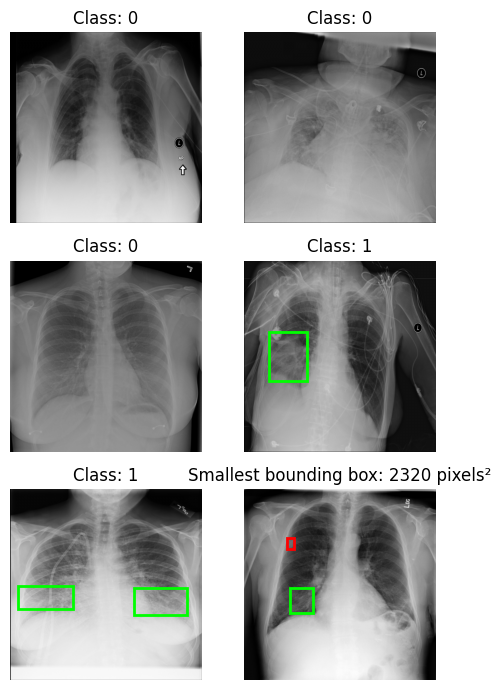

In [140]:
# Display at least six representative images: positive and negative examples, and the one with the smallest bounding box

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

positive_df = label_df[label_df["Target"] == 1].copy()
negative_df = label_df[label_df["Target"] == 0].copy()

# Locate the smallest box while retaining every box for its image.
positive_df["Smallest Box Area"] = positive_df["Bounding Boxes"].apply(
    lambda boxes: min(box["width"] * box["height"] for box in boxes)
)
smallest_row = positive_df.loc[positive_df["Smallest Box Area"].idxmin()]
smallest_box = min(
    smallest_row["Bounding Boxes"],
    key=lambda box: box["width"] * box["height"]
)
smallest_image_id = smallest_row["SOPInstanceUID"]

# Select three unique negatives and two other unique positives
negative_examples = (
    negative_df
    .sample(3, random_state=42)
)

positive_examples = (
    positive_df[positive_df["SOPInstanceUID"] != smallest_image_id]
    .sample(2, random_state=42)
)

displayed_dicom = pd.concat([
    negative_examples,
    positive_examples,
    smallest_row.to_frame().T
])

fig, axes = plt.subplots(3, 2, figsize=(5, 7))

for i, (_, row) in enumerate(displayed_dicom.iterrows()):
    ds = pydicom.dcmread(row["File Path"])
    image = ds.pixel_array

    ax = axes.flat[i]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Class: {row['Target']}")
    ax.axis("off")

    # Draw every box belonging to the image.
    for bounding_box in row["Bounding Boxes"]:
        is_smallest = i == 5 and bounding_box == smallest_box
        rectangle = Rectangle(
            (bounding_box["x"], bounding_box["y"]),
            bounding_box["width"],
            bounding_box["height"],
            edgecolor="red" if is_smallest else "lime",
            facecolor="none",
            linewidth=2
        )
        ax.add_patch(rectangle)

    if i == 5:
        ax.set_title(
            f"Smallest bounding box: {int(row['Smallest Box Area'])} pixels²"
        )

plt.tight_layout()
plt.show()

In [141]:
# Check image size, photometric interpretation and projection/view information when available
print("Image size counts:")
display(metadata_df.value_counts(["Rows", "Columns"], dropna=False).rename("Count").reset_index())

print("Photometric interpretation counts:")
display(metadata_df["Photometric Interpretation"].value_counts(dropna=False))

print("Projection/view counts:")
display(metadata_df["View Position"].value_counts(dropna=False)) # AP is Anterior Posterior / from the front

Image size counts:


,Rows,Columns,Count
0,1024,1024,25684


Photometric interpretation counts:


Photometric Interpretation
MONOCHROME2    25684
Name: count, dtype: int64

Projection/view counts:


View Position
PA    13979
AP    11705
Name: count, dtype: int64

## Create Splits

In [142]:


# train, val, and test split based on NIH data
from sklearn.model_selection import GroupShuffleSplit

split1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=67)
train_idx, temp_idx = next(split1.split(label_df, groups=label_df["nih_patient_id"]))

train_df = label_df.iloc[train_idx].reset_index(drop=True)
temp_df = label_df.iloc[temp_idx].reset_index(drop=True)

split2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=67)
val_idx, test_idx = next(split2.split(temp_df, groups=temp_df['nih_patient_id']))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# positive class proportion
print("Train")
display(train_df['Target'].value_counts() / len(train_df['Target']))
print("Val")
display(val_df['Target'].value_counts() / len(val_df['Target']))
print("Test")
display(test_df['Target'].value_counts() / len(test_df['Target']))

# verify no overlap
train_patients = set(train_df['nih_patient_id'])
val_patients = set(val_df['nih_patient_id'])
test_patients = set(test_df['nih_patient_id'])

assert(len(train_patients & val_patients) == 0)
assert(len(train_patients & test_patients) == 0)
assert(len(test_patients & val_patients) == 0)

print("Train-Val overlap:", train_patients & val_patients)
print("Train-Test overlap:", train_patients & test_patients)
print("Val-Test overlap:", val_patients & test_patients)

Train: 20658, val: 2480, test: 2546
Train


Target
0    0.779117
1    0.220883
Name: count, dtype: float64

Val


Target
0    0.774597
1    0.225403
Name: count, dtype: float64

Test


Target
0    0.789081
1    0.210919
Name: count, dtype: float64

Train-Val overlap: set()
Train-Test overlap: set()
Val-Test overlap: set()


In multi site dataset, there might be a leakage where the model already learn the pattern from all of the site on the data thus it might overfit to test data and perform poorly when used on site/place outside the collected data or in real world application. To handle this, we also need to consider the site on to the splitting, such as by excluding the data from a certain site on the train data so the test data result can reduce this impact

## Preprocessing and Augmentation

In [143]:
# convert dicom to tensor
# we use dataset so the data will gradually loaded to the ram when needed
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

DEVICE = torch.device("cuda")
BATCH_SIZE = 64
NUM_WORKERS = 4

class DICOM_dataset(Dataset):
    def __init__(self, df, image_col, label_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        path = self.df.loc[index, self.image_col]

        dcm = pydicom.dcmread(path)
        image = dcm.pixel_array.astype(np.float32)

        # rescale
        slope = float(getattr(dcm, "RescaleSlope", 1.0))
        intercept = float(getattr(dcm, "RescaleIntercept", 0.0))
        image = image * slope + intercept

        # normalize
        min_val = image.min()
        max_val = image.max()
        image = (image - min_val) / (max_val - min_val)

        image = torch.from_numpy(image).float().unsqueeze(0)
        image = image.repeat(3, 1, 1) # [3, H, W] so that it can be processed by resnet

        if self.transform:
            image = self.transform(image)

        label = self.df.loc[index, self.label_col]
        label = torch.tensor(label, dtype=torch.float32)

        return image, label


In [144]:
# training only augmentation
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode

eval_transform = T.Compose([
    T.Resize(
        (224, 224),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    ),
    T.Normalize(
        mean=[0.485, 0.456, 0.406], # given by the imagenet dataset
        std=[0.229, 0.224, 0.225]
    )
])

train_transform = T.Compose([
    T.Resize(
        (224, 224),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    ),
    T.RandomRotation(degrees=7, interpolation=InterpolationMode.BILINEAR,),
    T.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    T.RandomApply([
        T.ColorJitter(
            brightness=0.1,
            contrast=0.1
        )
    ], p=0.5),
    T.Normalize(
        mean=[0.485, 0.456, 0.406], # given by the imagenet dataset
        std=[0.229, 0.224, 0.225]
    )
])

In [145]:
train_dataset = DICOM_dataset(train_df, "File Path", "Target", transform=train_transform)
val_dataset = DICOM_dataset(val_df, "File Path", "Target", transform=eval_transform)
test_dataset = DICOM_dataset(test_df, "File Path", "Target", transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    # persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    # persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    # persistent_workers=True
)

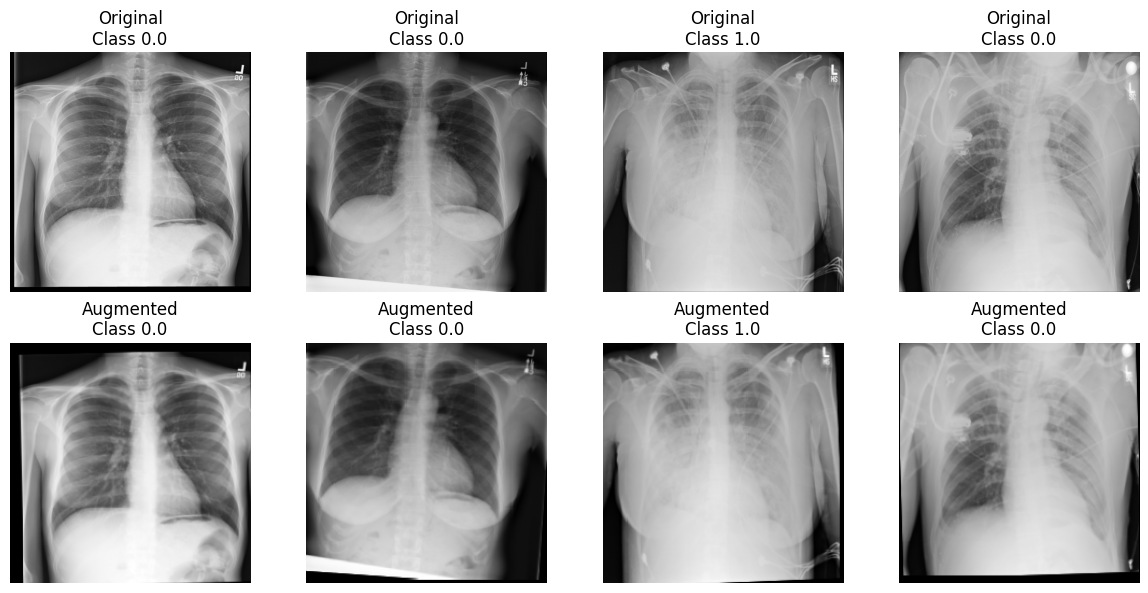

In [146]:
# example of train data with and without transform

train_dataset_transform = DICOM_dataset(train_df, "File Path", "Target", transform=train_transform)
train_transform_loader = DataLoader(
    train_dataset_transform,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

train_dataset_no_transform = DICOM_dataset(train_df, "File Path", "Target")
train_no_transform_loader = DataLoader(
    train_dataset_no_transform,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images_no_transform, labels_no_transform = next(iter(train_no_transform_loader))
images_transform, labels_transform = next(iter(train_transform_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    # Original
    axes[0, i].imshow(
        images_no_transform[i][0].squeeze().cpu().numpy(),
        cmap="gray"
    )
    axes[0, i].set_title(f"Original\nClass {labels_no_transform[i].item()}")
    axes[0, i].axis("off")

    # Augmented
    axes[1, i].imshow(
        images_transform[i][0].squeeze().cpu().numpy(),
        cmap="gray"
    )
    axes[1, i].set_title(f"Augmented\nClass {labels_transform[i].item()}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Evaluation function

In [147]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, recall_score, f1_score, precision_score

def evaluate(labels, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)

    conf_matrix = confusion_matrix(labels, predictions)
    tn, fp, fn, tp = conf_matrix.copy().ravel()

    return {
        "labels": labels,
        "probabilities": probabilities,
        "predictions": predictions,
        "confusion_matrix": conf_matrix,
        "accuracy": accuracy_score(labels, (probabilities >= threshold).astype(int)),
        "sensitivity": recall_score(labels, predictions),
        "specificity": tn / (tn + fp),
        "precision": precision_score(labels, predictions),
        "roc_auc": roc_auc_score(labels, probabilities),        
        "f1_score": f1_score(labels, (probabilities >= threshold).astype(int), average="binary")
    }

## Baseline

In [148]:
# extract numerical features from the image
def extract_feature_from_loader(loader, n_bins=32):
    X = []
    y = []

    for images, labels in loader:
        for image, label in zip(images, labels):
            pixels = image[0].squeeze().cpu().numpy().astype(np.float32) # just take one channel
            flat = pixels.ravel()

            features = [
                np.mean(flat),
                np.median(flat),
                np.std(flat),
                np.min(flat),
                np.max(flat),
                np.percentile(flat, 25),
                np.percentile(flat, 75),
            ]

            hist, _ = np.histogram(
                flat,
                bins=n_bins,
                range=(0, 1),
                density=True
            )

            features = np.concatenate([np.array(features),hist])
            X.append(features)
            y.append(label.item())

    return np.array(X), np.array(y)

In [149]:
# load feature if already ran before since it could take a while to run the extraction
import os

FEATURE_FILE = "data/xray_rf_features_image_level.npz"

if os.path.exists(FEATURE_FILE):
    print("loading saved features...")

    data = np.load(FEATURE_FILE)

    X_train = data["X_train"]
    y_train = data["y_train"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    X_test = data["X_test"]
    y_test = data["y_test"]

else:
    print("Feature file not found. Extracting features...")

    X_train, y_train = extract_feature_from_loader(train_loader)
    X_val, y_val = extract_feature_from_loader(val_loader)
    X_test, y_test = extract_feature_from_loader(test_loader)

    print("Saving features...")

    np.savez_compressed(
        FEATURE_FILE,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test
    )

    print(f"Saved to {FEATURE_FILE}")

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

loading saved features...
Train: (20658, 39) (20658,)
Val:   (2480, 39) (2480,)
Test:  (2546, 39) (2546,)


### Trivial Baseline

In [150]:
# since the majority is 0 (negative), a trivial baseline is to predict all as negative

y_val_prob = np.zeros(y_val.shape[0])
trivial_result = evaluate(y_val, y_val_prob)
trivial_result

/home/faiz.ramadhan/.conda/envs/myenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'labels': array([0., 1., 0., ..., 0., 0., 0.], shape=(2480,)),
 'probabilities': array([0., 0., 0., ..., 0., 0., 0.], shape=(2480,)),
 'predictions': array([0, 0, 0, ..., 0, 0, 0], shape=(2480,)),
 'confusion_matrix': array([[1921,    0],
        [ 559,    0]]),
 'accuracy': 0.7745967741935483,
 'sensitivity': 0.0,
 'specificity': np.float64(1.0),
 'precision': 0.0,
 'roc_auc': np.float64(0.5),
 'f1_score': 0.0}

### Simple Baseline

In [151]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, recall_score

# rf_model = RandomForestClassifier(n_estimators=100, random_state=67)
# rf_model.fit(X_train, y_train)

# y_val_pred = rf_model.predict(X_val)

# accuracy = accuracy_score(y_val, y_val_pred)
# classification_rep = classification_report(y_val, y_val_pred)

# print(f"Accuracy: {accuracy:.2f}")
# print("\nClassification Report:\n", classification_rep)

In [152]:
# # try tuning hyperparam with val and final eval with test
# from sklearn.model_selection import RandomizedSearchCV

# param_distributions = {
#     "n_estimators": [100, 200, 500],
#     "max_depth": [None, 5, 10, 30],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "class_weight": [None, "balanced"]
# }

# rf_model = RandomForestClassifier(n_estimators=100, random_state=67)
# random_search = RandomizedSearchCV(rf_model, param_distributions, n_iter=5, scoring="recall", random_state=67)

# random_search.fit(X_train, y_train)

# best_rf_model = random_search.best_estimator_
# y_val_pred = best_rf_model.predict(X_val)

# print("Best parameters:", random_search.best_params_)
# print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.2f}")
# print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

In [153]:
# # eval on test data
# y_test_pred = best_rf_model.predict(X_test)

# print("Best parameters:", random_search.best_params_)
# print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
# print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
# print(f"Recall: {recall_score(y_test, y_test_pred)}")

try 3 seeds

In [154]:
# ai to save and load the joblib
import os
import joblib
from sklearn.ensemble import RandomForestClassifier

THREE_SEEDS = [1, 2, 3]

os.makedirs("model", exist_ok=True)

rf_results = []

for seed in THREE_SEEDS:
    model_path = f"model/random_forest_seed_{seed}.joblib"

    if os.path.exists(model_path):
        print(f"Loading {model_path}")
        rf_model = joblib.load(model_path)
    else:
        print(f"Training Random Forest (seed={seed})")

        rf_model = RandomForestClassifier(
            n_estimators=500,
            min_samples_split=2,
            min_samples_leaf=4,
            max_depth=None,
            class_weight="balanced",
            random_state=seed
        )

        rf_model.fit(X_train, y_train)

        joblib.dump(rf_model, model_path)
        print(f"Saved to {model_path}")

    y_val_prob = rf_model.predict_proba(X_val)[:, 1]
    
    rf_results.append(evaluate(y_val, y_val_prob))

Loading model/random_forest_seed_1.joblib


Loading model/random_forest_seed_2.joblib
Loading model/random_forest_seed_3.joblib


In [155]:
for i in range(len(THREE_SEEDS)):
    print(rf_results[i])
rf_results_sensitivity = np.array([rf_results[i]['sensitivity'] for i in range(len(THREE_SEEDS))])
print(f"RF sensitivity mean: {rf_results_sensitivity.mean()}, std: {rf_results_sensitivity.std()}")

{'labels': array([0., 1., 0., ..., 0., 0., 0.], shape=(2480,)), 'probabilities': array([0.45525511, 0.07078568, 0.14575445, ..., 0.45502585, 0.12505436,
       0.12701721], shape=(2480,)), 'predictions': array([0, 0, 0, ..., 0, 0, 0], shape=(2480,)), 'confusion_matrix': array([[1704,  217],
       [ 334,  225]]), 'accuracy': 0.7778225806451613, 'sensitivity': 0.40250447227191416, 'specificity': np.float64(0.8870380010411244), 'precision': 0.5090497737556561, 'roc_auc': np.float64(0.7808470357288196), 'f1_score': 0.44955044955044954}
{'labels': array([0., 1., 0., ..., 0., 0., 0.], shape=(2480,)), 'probabilities': array([0.42961796, 0.06579591, 0.17943998, ..., 0.41473772, 0.11462378,
       0.09659893], shape=(2480,)), 'predictions': array([0, 0, 0, ..., 0, 0, 0], shape=(2480,)), 'confusion_matrix': array([[1707,  214],
       [ 334,  225]]), 'accuracy': 0.7790322580645161, 'sensitivity': 0.40250447227191416, 'specificity': np.float64(0.8885996876626757), 'precision': 0.5125284738041003

## Pretrained CNN (Resnet50 from pytorch)

In [156]:
import torch.nn as nn
from torchvision import models

def make_resnet50():
    resnet_model = models.resnet50(
        weights='IMAGENET1K_V2'
    )

    # freeze everything
    for param in resnet_model.parameters():
        param.requires_grad = False

    # unfreeze the final ResNet block
    for param in resnet_model.layer4.parameters():
        param.requires_grad = True

    fc_input_dim = resnet_model.fc.in_features
    resnet_model.fc = nn.Linear(fc_input_dim, 1)
    resnet_model.to(DEVICE)

    return resnet_model

resnet_model = make_resnet50()

In [157]:
total_params = sum(p.numel() for p in resnet_model.parameters())

trainable_params = sum(
    p.numel() for p in resnet_model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {frozen_params:,}")

Total parameters:     23,510,081
Trainable parameters: 14,966,785
Frozen parameters:    8,543,296


In [158]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True).float().reshape(-1)
        if training:
            optimizer.zero_grad()
        logits = model(x).reshape(-1)
        loss = criterion(logits, y)
        if training:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(x)
    return total_loss / len(loader.dataset)


def train_model(model, epochs, learning_rate, weight_decay, pos_weight=None, checkpoint_path="best_model.pth", seed = SEED):
    set_seed(seed) # set global seed
    
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    if pos_weight != None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float("inf")
    best_epoch = 0

    history = {"train": [], "validation": []}
    for epoch in range(epochs):
        train_loss = run_epoch(model, train_loader, criterion, optimizer)
        with torch.no_grad():
            validation_loss = run_epoch(model, val_loader, criterion)
        history["train"].append(train_loss)
        history["validation"].append(validation_loss)

        if validation_loss < best_val_loss:
            best_val_loss = validation_loss
            best_epoch = epoch + 1

            torch.save(model.state_dict(), checkpoint_path)

            print("Save best model, ", end='')

        print(f"Epoch {epoch + 1}: train loss={train_loss:.4f}, validation loss={validation_loss:.4f}")

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    
    print(f"Best Epoch: {best_epoch}, Best Val Loss: {best_val_loss}")
    
    return history

In [159]:
# temp_history = train_model(resnet_model, epochs=5, learning_rate=1e-4, weight_decay=1e-4, checkpoint_path='model_weight/best_model.pth')

# plt.plot(temp_history["train"], marker="o", label="Training")
# plt.plot(temp_history["validation"], marker="o", label="Validation")
# plt.xlabel("Epoch")
# plt.ylabel("Weighted BCE loss")
# plt.title("Resnet learning curves")
# plt.legend()
# plt.show()

Here we can see that the model is overfitting to the training data since the training loss keep decreasing while the validation loss is increasing. Because of this, we need to take/save the model that is the least overfit, which is the one that has the lowest validation loss.

In [160]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, recall_score, f1_score

def evaluate_model(model, loader, threshold=0.5, verbose=True):
    criterion = nn.BCEWithLogitsLoss()
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probabilities = []

    with torch.inference_mode():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True).float().reshape(-1)

            logits = model(x).reshape(-1)
            loss = criterion(logits, y)

            probabilities = torch.sigmoid(logits)

            total_loss += loss.item() * x.size(0)
            all_labels.append(y.cpu().numpy())
            all_probabilities.append(probabilities.cpu().numpy())

    labels = np.concatenate(all_labels).astype(int)
    probabilities = np.concatenate(all_probabilities)
    # predictions = (probabilities >= threshold).astype(int)

    # test_loss = total_loss / len(loader.dataset)

    return evaluate(labels, probabilities, threshold=threshold)

In [161]:
resnet_model.load_state_dict(
    torch.load(
        "model_weight/best_model.pth",
        map_location=DEVICE,
        weights_only=True
    )
)

resnet_model = resnet_model.to(DEVICE)

val_results = evaluate_model(
    resnet_model,
    test_loader,
    threshold=0.5
)

print(val_results)

{'labels': array([1, 0, 1, ..., 1, 0, 0], shape=(2546,)), 'probabilities': array([0.11003167, 0.00936187, 0.8646078 , ..., 0.70561856, 0.24758688,
       0.10729916], shape=(2546,), dtype=float32), 'predictions': array([0, 0, 1, ..., 1, 0, 0], shape=(2546,)), 'confusion_matrix': array([[1928,   81],
       [ 305,  232]]), 'accuracy': 0.8483896307934015, 'sensitivity': 0.43202979515828677, 'specificity': np.float64(0.9596814335490294), 'precision': 0.7412140575079872, 'roc_auc': np.float64(0.8665122405413999), 'f1_score': 0.5458823529411765}


### Try weighted loss

In [162]:
import torch.nn as nn
from torchvision import models

resnet_model = models.resnet50(
    weights='IMAGENET1K_V2'
)

# freeze everything
for param in resnet_model.parameters():
    param.requires_grad = False

# unfreeze the final ResNet block
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

fc_input_dim = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(fc_input_dim, 1)

resnet_model = resnet_model.to(DEVICE)

In [163]:
num_positive = (train_df["Target"] == 1).sum()
num_negative = (train_df["Target"] == 0).sum()

positive_weight = num_negative / num_positive

print(f"Negative: {num_negative}")
print(f"Positive: {num_positive}")
print(f"Positive weight: {positive_weight:.2f}")

pos_weight = torch.tensor(
    [positive_weight],
    dtype=torch.float32,
    device=DEVICE
)

Negative: 16095
Positive: 4563
Positive weight: 3.53


In [164]:
# temp_history = train_model(resnet_model, epochs=5, learning_rate=1e-4, weight_decay=1e-4, pos_weight=pos_weight, checkpoint_path='model_weight/best_model_weighted.pth')

# plt.plot(temp_history["train"], marker="o", label="Training")
# plt.plot(temp_history["validation"], marker="o", label="Validation")
# plt.xlabel("Epoch")
# plt.ylabel("Weighted BCE loss")
# plt.title("Resnet learning curves")
# plt.legend()
# plt.show()

Here we also see the same result where the model is overfit to the training data.

In [165]:
resnet_model.load_state_dict(
    torch.load(
        "model_weight/best_model_weighted.pth",
        map_location=DEVICE,
        weights_only=True
    )
)

resnet_model = resnet_model.to(DEVICE)

val_results = evaluate_model(
    resnet_model,
    val_loader,
    threshold=0.5
)

val_results

{'labels': array([0, 1, 0, ..., 0, 0, 0], shape=(2480,)),
 'probabilities': array([0.02314227, 0.15371265, 0.6052696 , ..., 0.86063015, 0.02420528,
        0.04750426], shape=(2480,), dtype=float32),
 'predictions': array([0, 0, 1, ..., 1, 0, 0], shape=(2480,)),
 'confusion_matrix': array([[1513,  408],
        [ 117,  442]]),
 'accuracy': 0.7883064516129032,
 'sensitivity': 0.7906976744186046,
 'specificity': np.float64(0.7876106194690266),
 'precision': 0.52,
 'roc_auc': np.float64(0.8632634873570433),
 'f1_score': 0.6273953158268275}

As we can see, the previous model (without weight loss adjustment) got 0.49 on the recall score. After we adjust the loss weight according to the number of data (so that it balance), it got a better result in terms of screening with 0.73 on the recall score. Because of this, we will continue with this weighted setup as our main cnn/resnet model

### Run on 3 seeds

In [166]:
# THREE_SEEDS = [1, 2, 3]
# resnet_histories = []

# for seed in THREE_SEEDS:
#     temp_resnet_model = make_resnet50()
#     resnet_histories.append(train_model(temp_resnet_model, epochs=5, learning_rate=1e-4, weight_decay=1e-4, pos_weight=pos_weight, checkpoint_path=f'model_weight/best_model_{seed}.pth', seed=seed))


# for i in range(len(THREE_SEEDS)):
#     plt.plot(resnet_histories[i]["train"], marker="o", label="Training")
#     plt.plot(resnet_histories[i]["validation"], marker="o", label="Validation")
#     plt.xlabel("Epoch")
#     plt.ylabel("Weighted BCE loss")
#     plt.title("Resnet learning curves")
#     plt.legend()
#     plt.show()



In [183]:
resnet_results = []
for i, seed in enumerate(THREE_SEEDS):
    temp_resnet_model = make_resnet50()
    temp_resnet_model.load_state_dict(
        torch.load(
            f"model_weight/best_model_{seed}.pth",
            map_location=DEVICE,
            weights_only=True
        )
    )
    
    # print(f"\nSeed: {seed}")
    result = evaluate_model(
        temp_resnet_model,
        val_loader,
        threshold=0.5,
        verbose=False
    )
    resnet_results.append(result)
    # print(result)

{'labels': array([0, 1, 0, ..., 0, 0, 0], shape=(2480,)), 'probabilities': array([0.00498036, 0.06578278, 0.23196544, ..., 0.6890992 , 0.0022352 ,
       0.02509247], shape=(2480,), dtype=float32), 'predictions': array([0, 0, 0, ..., 1, 0, 0], shape=(2480,)), 'confusion_matrix': array([[1627,  294],
       [ 157,  402]]), 'accuracy': 0.8181451612903226, 'sensitivity': 0.7191413237924866, 'specificity': np.float64(0.846954711087975), 'precision': 0.5775862068965517, 'roc_auc': np.float64(0.8714136849192476), 'f1_score': 0.6406374501992032}
{'labels': array([0, 1, 0, ..., 0, 0, 0], shape=(2480,)), 'probabilities': array([0.07348683, 0.14364766, 0.20854469, ..., 0.8135502 , 0.02359491,
       0.13376886], shape=(2480,), dtype=float32), 'predictions': array([0, 0, 0, ..., 1, 0, 0], shape=(2480,)), 'confusion_matrix': array([[1575,  346],
       [ 149,  410]]), 'accuracy': 0.8004032258064516, 'sensitivity': 0.7334525939177102, 'specificity': np.float64(0.8198854763144195), 'precision': 0.54

In [168]:
resnet_results_sensitivity = np.array([resnet_results[i]['sensitivity'] for i in range(len(THREE_SEEDS))])
print(f"Resnet Recall mean: {resnet_results_sensitivity.mean()}, std: {resnet_results_sensitivity.std()}")
print(f"RF Recall mean: {rf_results_sensitivity.mean()}, std: {rf_results_sensitivity.std()}")

Resnet Recall mean: 0.738819320214669, std: 0.018648176232691563
RF Recall mean: 0.40310077519379844, std: 0.0008432996794114851


As we can see that the recall mean of resnet is higher than random forest model

# Evaluate Performance

For this part we only use the first seed of the previous run for efficiency

Random Forest
{'labels': array([0., 1., 0., ..., 0., 0., 0.], shape=(2480,)), 'probabilities': array([0.45525511, 0.07078568, 0.14575445, ..., 0.45502585, 0.12505436,
       0.12701721], shape=(2480,)), 'predictions': array([0, 0, 0, ..., 0, 0, 0], shape=(2480,)), 'confusion_matrix': array([[1704,  217],
       [ 334,  225]]), 'accuracy': 0.7778225806451613, 'sensitivity': 0.40250447227191416, 'specificity': np.float64(0.8870380010411244), 'precision': 0.5090497737556561, 'roc_auc': np.float64(0.7808470357288196), 'f1_score': 0.44955044955044954}

ResNet
{'labels': array([0, 1, 0, ..., 0, 0, 0], shape=(2480,)), 'probabilities': array([0.00498036, 0.06578278, 0.23196544, ..., 0.6890992 , 0.0022352 ,
       0.02509247], shape=(2480,), dtype=float32), 'predictions': array([0, 0, 0, ..., 1, 0, 0], shape=(2480,)), 'confusion_matrix': array([[1627,  294],
       [ 157,  402]]), 'accuracy': 0.8181451612903226, 'sensitivity': 0.7191413237924866, 'specificity': np.float64(0.846954711087975), 'p

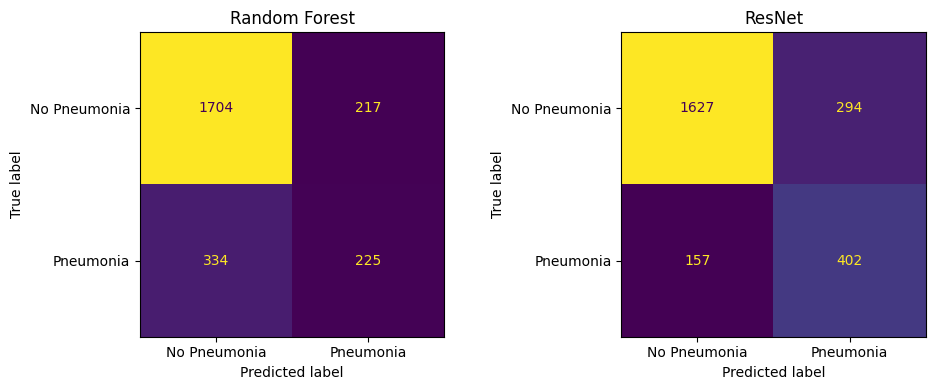

In [169]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("Random Forest")
print(rf_results[0])

print("\nResNet")
print(resnet_results[0])

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix=rf_results[0]["confusion_matrix"],
    display_labels=["No Pneumonia", "Pneumonia"]
).plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(
    confusion_matrix=resnet_results[0]["confusion_matrix"],
    display_labels=["No Pneumonia", "Pneumonia"]
).plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("ResNet")

plt.tight_layout()
plt.show()

as we can see the false negative is lower in resnet compared to random forest

In [170]:
results_df = pd.DataFrame({"Random Forest": rf_results[0], "Resnet": resnet_results[0]}).T
results_df

,labels,probabilities,predictions,confusion_matrix,accuracy,sensitivity,specificity,precision,roc_auc,f1_score
Random Forest,"[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0.45525510619161014, 0.07078567976843857, 0.1...","[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, ...","[[1704, 217], [334, 225]]",0.777823,0.402504,0.887038,0.50905,0.780847,0.44955
Resnet,"[0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, ...","[0.00498036, 0.06578278, 0.23196544, 0.0001586...","[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, ...","[[1627, 294], [157, 402]]",0.818145,0.719141,0.846955,0.577586,0.871414,0.640637


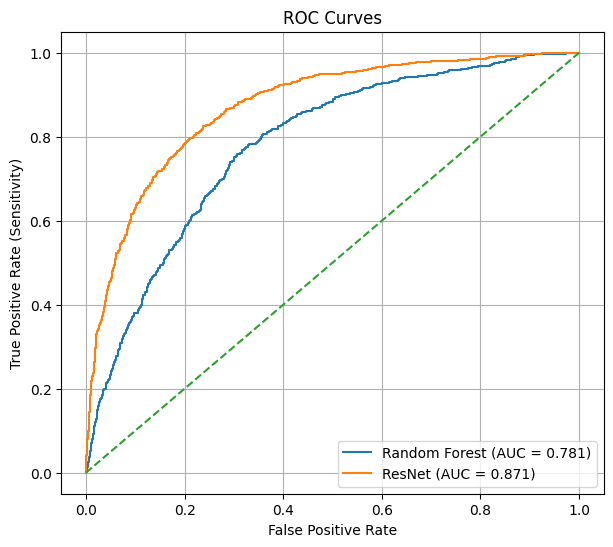

In [171]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

rf_fpr, rf_tpr, _ = roc_curve(rf_results[0]['labels'], rf_results[0]['probabilities'])
resnet_fpr, resnet_tpr, _ = roc_curve(resnet_results[0]['labels'], resnet_results[0]['probabilities'])

rf_auc = roc_auc_score(rf_results[0]['labels'], rf_results[0]['probabilities'])
resnet_auc = roc_auc_score(resnet_results[0]['labels'], resnet_results[0]['probabilities'])

plt.figure(figsize=(7, 6))

plt.plot(
    rf_fpr, rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    resnet_fpr, resnet_tpr,
    label=f"ResNet (AUC = {resnet_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

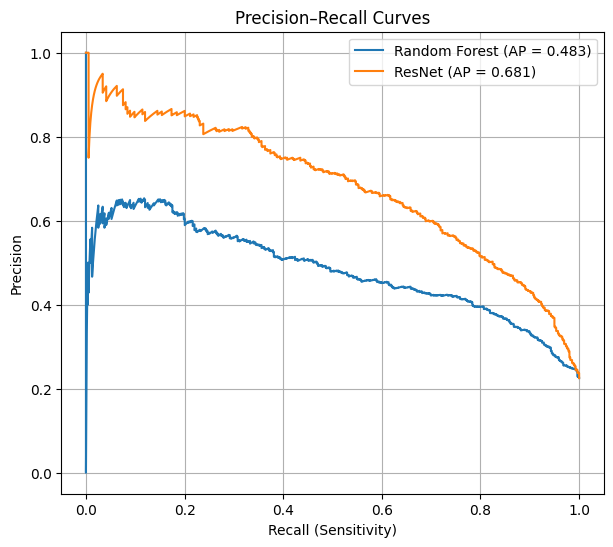

In [172]:
from sklearn.metrics import precision_recall_curve, average_precision_score

rf_precision, rf_recall, _ = precision_recall_curve(rf_results[0]['labels'], rf_results[0]['probabilities'])
resnet_precision, resnet_recall, _ = precision_recall_curve(resnet_results[0]['labels'], resnet_results[0]['probabilities'])

rf_ap = average_precision_score(rf_results[0]['labels'], rf_results[0]['probabilities'])
resnet_ap = average_precision_score(resnet_results[0]['labels'], resnet_results[0]['probabilities'])

plt.figure(figsize=(7, 6))

plt.plot(
    rf_recall, rf_precision,
    label=f"Random Forest (AP = {rf_ap:.3f})"
)

plt.plot(
    resnet_recall, resnet_precision,
    label=f"ResNet (AP = {resnet_ap:.3f})"
)

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid()
plt.show()

The Precision–Recall curve is more informative for this dataset because healthy cases significantly outnumber positive pneumonia cases. In ROC curves, a large number of true negatives inflates the denominator of the False Positive Rate, making model performance appear deceptively high. In contrast, the Precision–Recall curve isolates the positive class by measuring precision, revealing a clearer picture of false positive errors that ROC curves conceal

### Select Threshold

In [173]:
# help with ai
def get_threshold_metrics(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true, predictions, labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    return sensitivity, specificity


def select_thresholds(result):
    y_true = result["labels"]
    probabilities = result["probabilities"]

    thresholds = np.unique(probabilities)

    metrics = []

    for threshold in thresholds:
        sensitivity, specificity = get_threshold_metrics(
            y_true, probabilities, threshold
        )

        metrics.append({
            "threshold": threshold,
            "sensitivity": sensitivity,
            "specificity": specificity
        })

    # Screening:
    # highest threshold that still achieves >= 90% sensitivity
    screening_candidates = [
        x for x in metrics
        if x["sensitivity"] >= 0.90
    ]

    screening = max(
        screening_candidates,
        key=lambda x: x["threshold"]
    )

    # High specificity:
    # lowest threshold that achieves >= 90% specificity
    specificity_candidates = [
        x for x in metrics
        if x["specificity"] >= 0.90
    ]

    high_specificity = min(
        specificity_candidates,
        key=lambda x: x["threshold"]
    )

    return screening, high_specificity

In [174]:
rf_threshold = select_thresholds(rf_results[0])
resnet_threshold = select_thresholds(resnet_results[0])

print("RF Threshold")
print(rf_threshold) # first one for screening/high sensitivity and second one for high specificity

print("\nResnet Threshold")
print(resnet_threshold)

RF Threshold
({'threshold': np.float64(0.18278192215177264), 'sensitivity': np.float64(0.9016100178890877), 'specificity': np.float64(0.4726704841228527)}, {'threshold': np.float64(0.5157337713462928), 'sensitivity': np.float64(0.3810375670840787), 'specificity': np.float64(0.9000520562207184)})

Resnet Threshold
({'threshold': np.float32(0.16747782), 'sensitivity': np.float64(0.9016100178890877), 'specificity': np.float64(0.6553878188443519)}, {'threshold': np.float32(0.63215333), 'sensitivity': np.float64(0.629695885509839), 'specificity': np.float64(0.9000520562207184)})


In [175]:
# screening

final_rf_model = joblib.load("model/random_forest_seed_1.joblib")
y_test_prob = final_rf_model.predict_proba(X_test)[:, 1]
screening_rf_result = evaluate(y_test, y_test_prob, threshold=rf_threshold[0]['threshold'])

final_resnet_model = make_resnet50()
final_resnet_model.load_state_dict(
    torch.load(
        f"model_weight/best_model_1.pth",
        map_location=DEVICE,
        weights_only=True
    )
)

screening_resnet_result = evaluate_model(
    final_resnet_model,
    test_loader,
    threshold=resnet_threshold[0]['threshold'],
    verbose=False
)

print("RF: ")
print(screening_rf_result)

print("\nResnet: ")
print(screening_resnet_result)

print(f"RF sensitivity: {screening_rf_result['sensitivity']}")
print(f"Resnet sensitivity: {screening_resnet_result['sensitivity']}")

RF: 
{'labels': array([1., 0., 1., ..., 1., 0., 0.], shape=(2546,)), 'probabilities': array([0.3034845 , 0.02481971, 0.49227297, ..., 0.5392007 , 0.41818358,
       0.67552948], shape=(2546,)), 'predictions': array([1, 0, 1, ..., 1, 1, 1], shape=(2546,)), 'confusion_matrix': array([[ 982, 1027],
       [  59,  478]]), 'accuracy': 0.5734485467399842, 'sensitivity': 0.8901303538175046, 'specificity': np.float64(0.4888003982080637), 'precision': 0.3176079734219269, 'roc_auc': np.float64(0.7845004741234277), 'f1_score': 0.4681684622918707}

Resnet: 
{'labels': array([1, 0, 1, ..., 1, 0, 0], shape=(2546,)), 'probabilities': array([3.9414465e-01, 5.3725590e-04, 9.8443294e-01, ..., 9.5525485e-01,
       1.5578075e-01, 3.4867191e-01], shape=(2546,), dtype=float32), 'predictions': array([1, 0, 1, ..., 1, 0, 1], shape=(2546,)), 'confusion_matrix': array([[1359,  650],
       [  64,  473]]), 'accuracy': 0.7195600942655145, 'sensitivity': 0.8808193668528864, 'specificity': np.float64(0.67645594823

In [176]:
# high_specificity

final_rf_model = joblib.load("model/random_forest_seed_1.joblib")
y_test_prob = final_rf_model.predict_proba(X_test)[:, 1]
high_specificity_rf_result = evaluate(y_test, y_test_prob, threshold=rf_threshold[1]['threshold'])

final_resnet_model = make_resnet50()
final_resnet_model.load_state_dict(
    torch.load(
        f"model_weight/best_model_1.pth",
        map_location=DEVICE,
        weights_only=True
    )
)

high_specificity_resnet_result = evaluate_model(
    final_resnet_model,
    test_loader,
    threshold=resnet_threshold[1]['threshold'],
    verbose=False
)

print("RF Result: ")
print(high_specificity_rf_result)

print("\nResnet Result: ")
print(high_specificity_resnet_result)

print(f"RF specificity: {high_specificity_rf_result['specificity']}")
print(f"Resnet specificity: {high_specificity_resnet_result['specificity']}")

RF Result: 
{'labels': array([1., 0., 1., ..., 1., 0., 0.], shape=(2546,)), 'probabilities': array([0.3034845 , 0.02481971, 0.49227297, ..., 0.5392007 , 0.41818358,
       0.67552948], shape=(2546,)), 'predictions': array([0, 0, 0, ..., 1, 0, 1], shape=(2546,)), 'confusion_matrix': array([[1839,  170],
       [ 339,  198]]), 'accuracy': 0.8000785545954439, 'sensitivity': 0.3687150837988827, 'specificity': np.float64(0.9153807864609258), 'precision': 0.5380434782608695, 'roc_auc': np.float64(0.7845004741234277), 'f1_score': 0.4375690607734807}

Resnet Result: 
{'labels': array([1, 0, 1, ..., 1, 0, 0], shape=(2546,)), 'probabilities': array([3.9414465e-01, 5.3725590e-04, 9.8443294e-01, ..., 9.5525485e-01,
       1.5578075e-01, 3.4867191e-01], shape=(2546,), dtype=float32), 'predictions': array([0, 0, 1, ..., 1, 0, 0], shape=(2546,)), 'confusion_matrix': array([[1822,  187],
       [ 217,  320]]), 'accuracy': 0.8413197172034564, 'sensitivity': 0.595903165735568, 'specificity': np.float64(

We can see that the result transfer the test data, where sensitivity is high in screening and specificity is high in the other one

### Reliability diagram

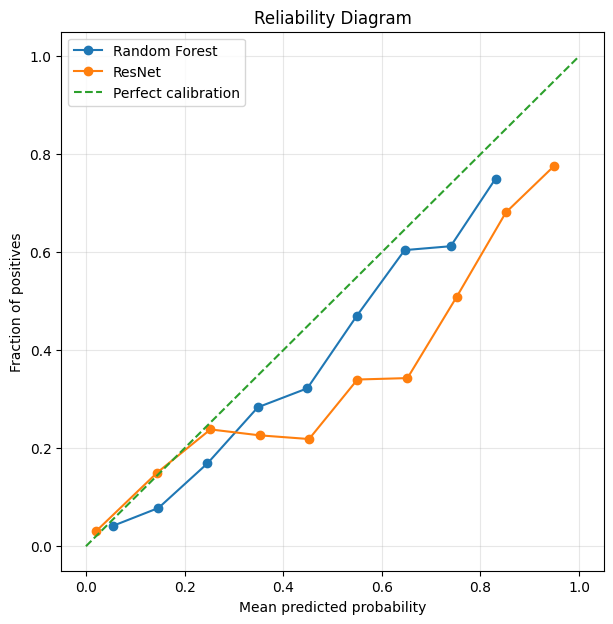

rf [0.04190476 0.07807309 0.16908213 0.28353659 0.32222222 0.46976744
 0.60431655 0.6122449  0.75      ] [0.05562082 0.14707634 0.24645458 0.3485405  0.44885231 0.54894559
 0.64624549 0.73955818 0.83051277]
resnet [0.03084416 0.1504065  0.23837209 0.22627737 0.21875    0.34020619
 0.34313725 0.50943396 0.68115942 0.77659574] [0.02078504 0.14470079 0.25244884 0.35233449 0.45241001 0.55050447
 0.65196107 0.75205279 0.85149128 0.94987528]


In [185]:
from sklearn.calibration import calibration_curve

# Random Forest
rf_true_prob, rf_pred_prob = calibration_curve(
    screening_rf_result["labels"],
    screening_rf_result["probabilities"],
    n_bins=10,
    strategy="uniform"
)

# ResNet
resnet_true_prob, resnet_pred_prob = calibration_curve(
    screening_resnet_result["labels"],
    screening_resnet_result["probabilities"],
    n_bins=10,
    strategy="uniform"
)

# Plot
plt.figure(figsize=(7, 7))

plt.plot(
    rf_pred_prob,
    rf_true_prob,
    marker="o",
    label="Random Forest"
)

plt.plot(
    resnet_pred_prob,
    resnet_true_prob,
    marker="o",
    label="ResNet"
)

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Reliability Diagram")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("rf", rf_true_prob, rf_pred_prob)
print("resnet", resnet_true_prob, resnet_pred_prob)

Here we can see that random forest is actually more calibrated compared to resnet, even though resnet sensitivity/recall is better

# Interpretation and Errors

### Look into error sample

Threshold = 0.1675
TP = 473, TN = 1359, FP = 650, FN = 64


,group,count
0,True Positive,473
1,True Negative,1359
2,False Positive,650
3,False Negative,64


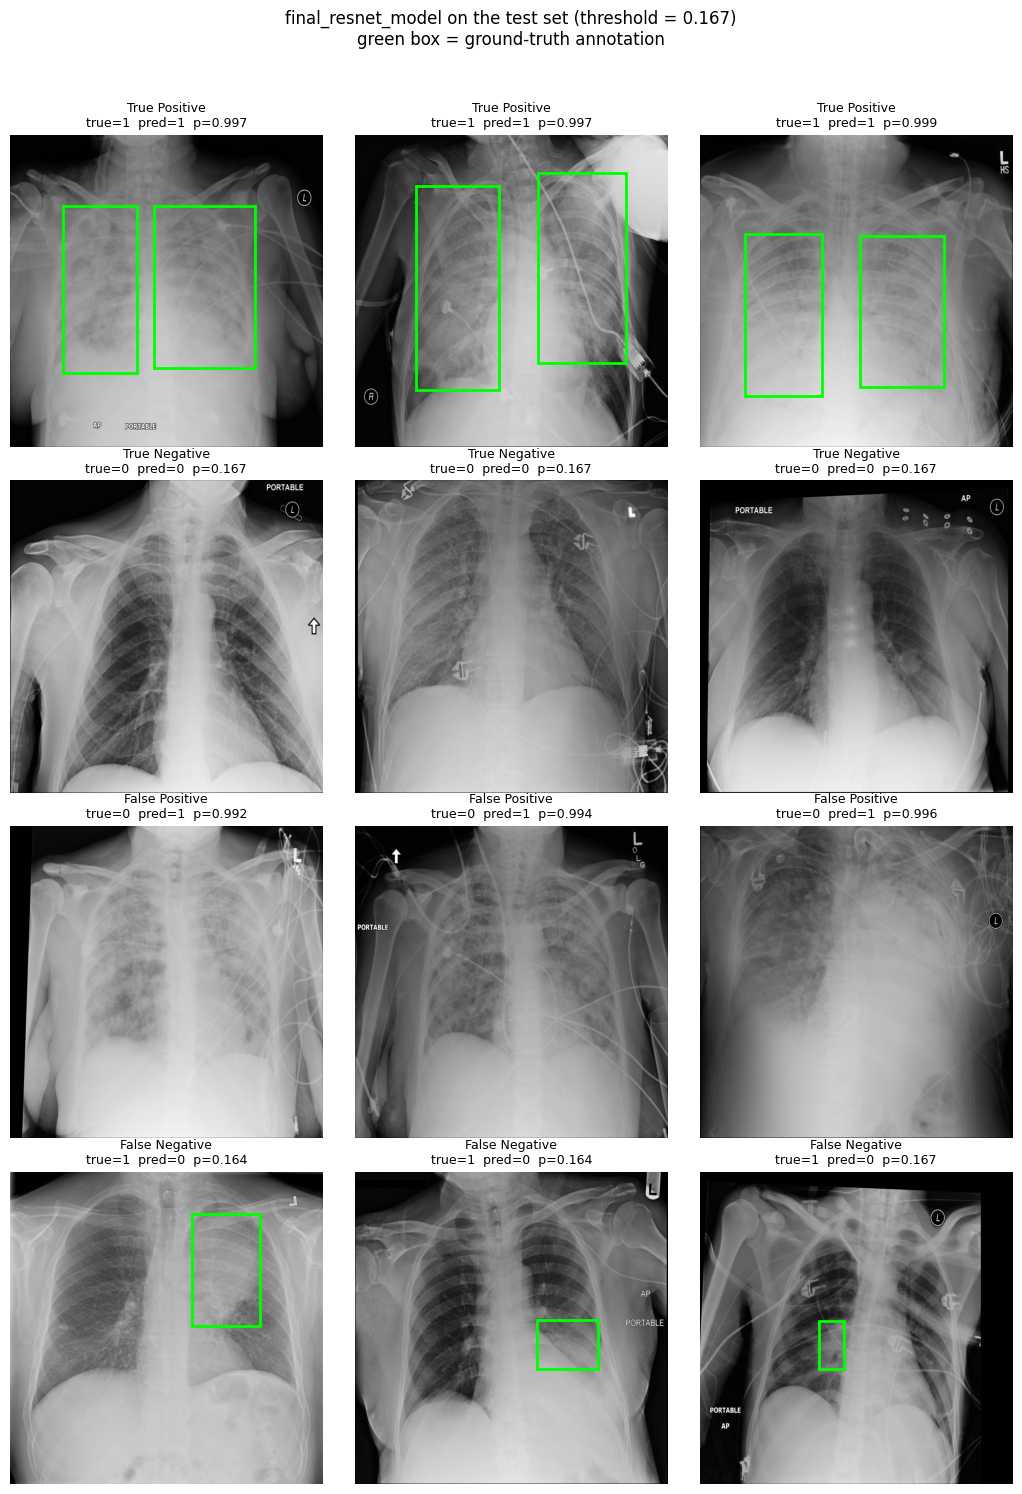

In [187]:
# use the previous screening result, use ai
probabilities = np.asarray(screening_resnet_result["probabilities"])
predictions = np.asarray(screening_resnet_result["predictions"])
labels = screening_rf_result["labels"]

THRESHOLD = resnet_threshold[0]['threshold']

groups = {
    "True Positive":  (labels == 1) & (predictions == 1),
    "True Negative":  (labels == 0) & (predictions == 0),
    "False Positive": (labels == 0) & (predictions == 1),
    "False Negative": (labels == 1) & (predictions == 0),
}

tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()

summary = pd.DataFrame(
    [{"group": name, "count": int(mask.sum())} for name, mask in groups.items()]
)

print(f"Threshold = {THRESHOLD:.4f}")
print(f"TP = {tp}, TN = {tn}, FP = {fp}, FN = {fn}")
display(summary)

N_EXAMPLES = 3
HOW = "most_confident"  # "median", "most_confident", "borderline" or "random"

def select_examples(mask, probs, n=N_EXAMPLES, how=HOW, seed=SEED):
    candidates = np.flatnonzero(mask)

    if len(candidates) == 0:
        return candidates
    if len(candidates) <= n:
        return candidates

    # Order candidates from least to most confident for this decision.
    by_confidence = candidates[np.argsort(probs[candidates])]

    if how == "most_confident":
        return by_confidence[-n:]
    if how == "borderline":
        return by_confidence[:n]
    if how == "random":
        return np.random.default_rng(seed).choice(candidates, size=n, replace=False)

    # "median": spread the picks across the confidence range so we see typical
    # behaviour instead of only the easiest or the most confusing cases.
    quantiles = np.linspace(0, 1, n + 2)[1:-1]
    return np.unique(np.quantile(by_confidence, quantiles).astype(int))

# --- 4. Draw them ------------------------------------------------------------
fig, axes = plt.subplots(
    len(groups), N_EXAMPLES,
    figsize=(3.5 * N_EXAMPLES, 3.8 * len(groups)),
    squeeze=False
)

for row, (name, mask) in enumerate(groups.items()):
    picks = select_examples(mask, probabilities)

    if len(picks) == 0:
        for col in range(N_EXAMPLES):
            axes[row, col].axis("off")
        axes[row, 0].text(
            0.5, 0.5, f"{name}\nno examples at this threshold",
            ha="center", va="center", transform=axes[row, 0].transAxes
        )
        continue

    for col, test_index in enumerate(picks):
        ax = axes[row, col]
        record = test_df.iloc[test_index]

        image = pydicom.dcmread(record["File Path"]).pixel_array
        ax.imshow(image, cmap="gray")

        # Ground-truth annotation, only present on positive images.
        for box in record["Bounding Boxes"]:
            ax.add_patch(Rectangle(
                (box["x"], box["y"]),
                box["width"],
                box["height"],
                edgecolor="lime",
                facecolor="none",
                linewidth=2
            ))

        ax.set_title(
            f"{name}\n"
            f"true={record['Target']}  pred={predictions[test_index]}  "
            f"p={probabilities[test_index]:.3f}",
            fontsize=9
        )
        ax.axis("off")

plt.suptitle(
    f"final_resnet_model on the test set (threshold = {THRESHOLD:.3f})\n"
    "green box = ground-truth annotation",
    fontsize=12
)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

### PA and AP comparison

Test images: 2546
Patients:    1118



,subgroup,images,share of test,patients,images per patient,positives,negatives,positive rate,large enough
0,AP,1134,0.445405,410,2.765854,404,730,0.356261,True
1,PA,1412,0.554595,918,1.538126,133,1279,0.094193,True
2,All,2546,1.000000,1118,2.277281,537,2009,0.210919,True



Threshold = 0.1675 (single global operating point, not tuned per subgroup)



,subgroup,n,positives,sensitivity,sensitivity 95% CI,specificity,specificity 95% CI,precision,f1,roc_auc
0,AP,1134,404,0.935644,"(0.9073735554862846, 0.9557066207389951)",0.431507,"(0.39602828445513916, 0.46770252611760577)",0.476671,0.631579,0.813685
1,PA,1412,133,0.714286,"(0.6323395003303363, 0.7842004992019698)",0.816263,"(0.7941019239547757, 0.8365293246732701)",0.287879,0.410367,0.866355
2,All,2546,537,0.880819,"(0.8506741778755509, 0.9055546329259851)",0.676456,"(0.65567843027893, 0.696559917736135)",0.421193,0.569880,0.869794


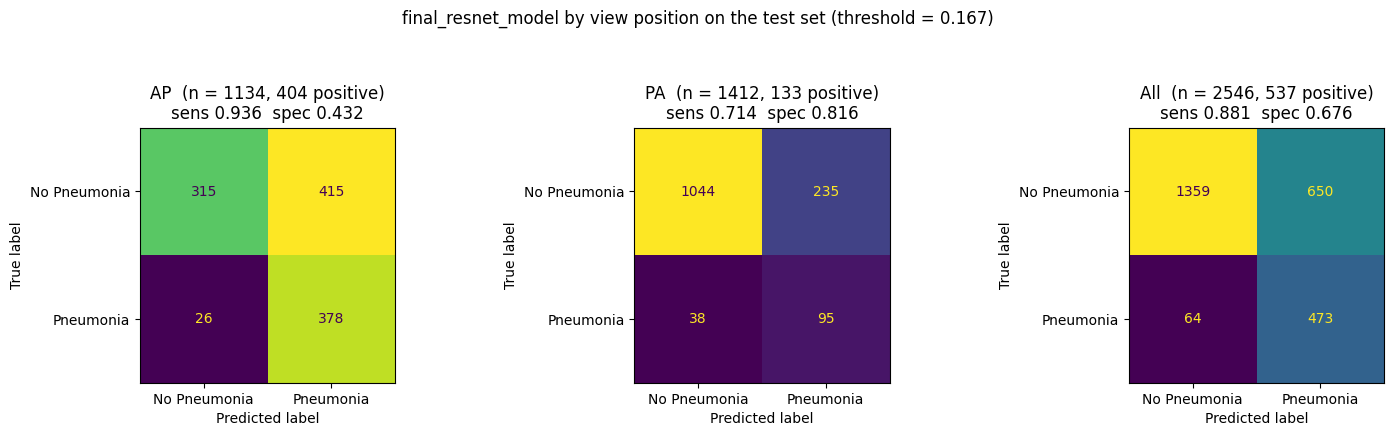

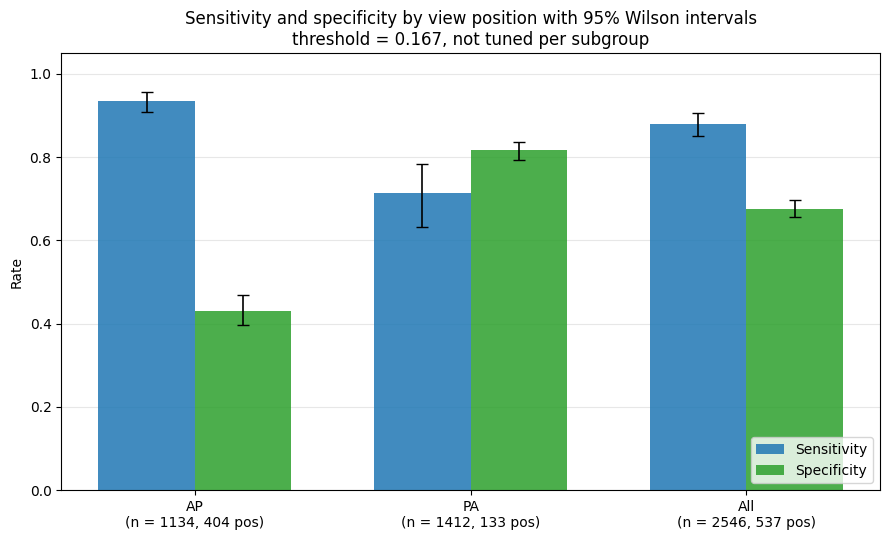

In [179]:
# use ai
# ---------------------------------------------------------------------------
# 1. Attach the subgroup label to the test set
# ---------------------------------------------------------------------------
GROUP_COLUMN = "View Position"

# One row per DICOM file, so this is a safe 1:1 lookup on the file path.
view_lookup = (
    metadata_df[["File Path", GROUP_COLUMN]]
    .drop_duplicates(subset="File Path")
)

subgroup_df = test_df.merge(view_lookup, on="File Path", how="left")

unmatched = subgroup_df[GROUP_COLUMN].isna().sum()
assert unmatched == 0, f"{unmatched} test images have no {GROUP_COLUMN} value"

# Guard against the silent row-multification that a many-to-many merge causes.
assert len(subgroup_df) == len(test_df), "Merge changed the number of test rows"
assert subgroup_df["SOPInstanceUID"].is_unique, "Test rows are no longer unique"

print(f"Test images: {len(subgroup_df)}")
print(f"Patients:    {subgroup_df['nih_patient_id'].nunique()}")

# ---------------------------------------------------------------------------
# 2. Subgroup sizes
# ---------------------------------------------------------------------------
# A rate estimated from few positives has a confidence interval far too wide to
# support any claim, so the count of positives and negatives is reported first
# and used to decide whether the rates are worth reading at all.
MIN_CLASS_COUNT = 30

size_rows = []

for name, group in subgroup_df.groupby(GROUP_COLUMN):
    positives = int((group["Target"] == 1).sum())
    negatives = len(group) - positives

    size_rows.append({
        "subgroup": name,
        "images": len(group),
        "share of test": len(group) / len(subgroup_df),
        "patients": group["nih_patient_id"].nunique(),
        "images per patient": len(group) / group["nih_patient_id"].nunique(),
        "positives": positives,
        "negatives": negatives,
        "positive rate": positives / len(group),
        "large enough": min(positives, negatives) >= MIN_CLASS_COUNT,
    })

# The pooled row is the benchmark the subgroups should be read against.
size_rows.append({
    "subgroup": "All",
    "images": len(subgroup_df),
    "share of test": 1.0,
    "patients": subgroup_df["nih_patient_id"].nunique(),
    "images per patient": len(subgroup_df) / subgroup_df["nih_patient_id"].nunique(),
    "positives": int((subgroup_df["Target"] == 1).sum()),
    "negatives": int((subgroup_df["Target"] == 0).sum()),
    "positive rate": float(subgroup_df["Target"].mean()),
    "large enough": min(
        int((subgroup_df["Target"] == 1).sum()),
        int((subgroup_df["Target"] == 0).sum()),
    ) >= MIN_CLASS_COUNT,
})

size_df = pd.DataFrame(size_rows)

print()
display(size_df)

small = size_df[~size_df["large enough"]]["subgroup"].tolist()
if small:
    print(
        f"CAUTION: {', '.join(small)} has fewer than {MIN_CLASS_COUNT} images in "
        "one of the two classes. Rates for these rows are descriptive only."
    )

# ---------------------------------------------------------------------------
# 3. Metrics per subgroup at the fixed screening threshold
# ---------------------------------------------------------------------------
THRESHOLD = resnet_threshold[0]["threshold"]

probabilities = np.asarray(screening_resnet_result["probabilities"])
labels = test_df["Target"].to_numpy()

assert len(probabilities) == len(subgroup_df), "Prediction order does not match the test set"


def wilson_interval(successes, total, z=1.96):
    """Wilson score interval for a proportion.

    Preferred over the normal approximation because it stays inside [0, 1] and
    does not collapse when the observed rate is 0% or 100%, both of which occur
    in the small subgroups here.
    """
    if total == 0:
        return (float("nan"), float("nan"))

    p = successes / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator

    return (max(0.0, centre - margin), min(1.0, centre + margin))


def evaluate_subgroup(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    positive_rate = y_true.mean()

    # AUC is undefined when a subgroup contains a single class.
    roc_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan

    return {
        "confusion_matrix": np.array([[tn, fp], [fn, tp]]),
        "sensitivity": sensitivity,
        "sensitivity CI": wilson_interval(tp, tp + fn),
        "specificity": specificity,
        "specificity CI": wilson_interval(tn, tn + fp),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "accuracy": (tp + tn) / len(y_true),
        "np": int((y_true == 1).sum()),
        "nn": int((y_true == 0).sum()),
        "n": len(y_true),
        "positive rate": positive_rate,
    }


metric_rows = []
results_by_subgroup = {}

for name, group in subgroup_df.groupby(GROUP_COLUMN):
    positions = group.index.to_numpy()
    result = evaluate_subgroup(
        subgroup_df.loc[positions, "Target"],
        probabilities[positions],
        THRESHOLD,
    )
    results_by_subgroup[name] = result

    metric_rows.append({
        "subgroup": name,
        "n": result["n"],
        "positives": result["np"],
        "sensitivity": result["sensitivity"],
        "sensitivity 95% CI": result["sensitivity CI"],
        "specificity": result["specificity"],
        "specificity 95% CI": result["specificity CI"],
        "precision": result["precision"],
        "f1": result["f1"],
        "roc_auc": result["roc_auc"],
    })

overall = evaluate_subgroup(labels, probabilities, THRESHOLD)
results_by_subgroup["All"] = overall

metric_rows.append({
    "subgroup": "All",
    "n": overall["n"],
    "positives": overall["np"],
    "sensitivity": overall["sensitivity"],
    "sensitivity 95% CI": overall["sensitivity CI"],
    "specificity": overall["specificity"],
    "specificity 95% CI": overall["specificity CI"],
    "precision": overall["precision"],
    "f1": overall["f1"],
    "roc_auc": overall["roc_auc"],
})

metric_df = pd.DataFrame(metric_rows)

print(f"\nThreshold = {THRESHOLD:.4f} (single global operating point, not tuned per subgroup)")
print()
display(metric_df)

# ---------------------------------------------------------------------------
# 4. Confusion matrices per subgroup
# ---------------------------------------------------------------------------
subgroup_names = list(results_by_subgroup.keys())
display_labels = ["No Pneumonia", "Pneumonia"]

fig, axes = plt.subplots(1, len(subgroup_names), figsize=(5 * len(subgroup_names), 4.4))

axes = np.atleast_1d(axes)

for ax, name in zip(axes, subgroup_names):
    result = results_by_subgroup[name]

    ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=display_labels,
    ).plot(ax=ax, values_format="d", colorbar=False)

    ax.set_title(
        f"{name}  (n = {result['n']}, {result['np']} positive)\n"
        f"sens {result['sensitivity']:.3f}  spec {result['specificity']:.3f}"
    )

plt.suptitle(
    f"final_resnet_model by {GROUP_COLUMN.lower()} on the test set "
    f"(threshold = {THRESHOLD:.3f})",
    fontsize=12,
)
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

# ---------------------------------------------------------------------------
# 5. Rates with confidence intervals
# ---------------------------------------------------------------------------
# The intervals are the point of this figure. Overlapping intervals mean the
# apparent AP/PA gap is not separable from sampling noise at this sample size.
plot_names = [name for name in subgroup_names if name != "All"] + ["All"]

positions_x = np.arange(len(plot_names))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))

for offset, key, label, colour in [
    (-bar_width / 2, "sensitivity", "Sensitivity", "tab:blue"),
    (bar_width / 2, "specificity", "Specificity", "tab:green"),
]:
    values = [results_by_subgroup[name][key] for name in plot_names]
    lower = [results_by_subgroup[name][f"{key} CI"][0] for name in plot_names]
    upper = [results_by_subgroup[name][f"{key} CI"][1] for name in plot_names]

    errors = np.array([
        [value - lo for value, lo in zip(values, lower)],
        [hi - value for value, hi in zip(values, upper)],
    ])

    ax.bar(
        positions_x + offset,
        values,
        width=bar_width,
        label=label,
        color=colour,
        alpha=0.85,
    )
    ax.errorbar(
        positions_x + offset,
        values,
        yerr=errors,
        fmt="none",
        ecolor="black",
        capsize=4,
        linewidth=1.2,
    )

ax.set_xticks(positions_x)
ax.set_xticklabels([
    f"{name}\n(n = {results_by_subgroup[name]['n']}, "
    f"{results_by_subgroup[name]['np']} pos)"
    for name in plot_names
])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Rate")
ax.set_title(
    f"Sensitivity and specificity by {GROUP_COLUMN.lower()} with 95% Wilson intervals\n"
    f"threshold = {THRESHOLD:.3f}, not tuned per subgroup"
)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


### Grad CAM visualization

Showing 12 images: 6 correct, 6 incorrect
  True Positive   test row 1120   true=1 pred=1 p=0.607
  True Positive   test row 1524   true=1 pred=1 p=0.937
  True Positive   test row 1812   true=1 pred=1 p=0.364
  True Negative   test row 1051   true=0 pred=0 p=0.011
  True Negative   test row 1419   true=0 pred=0 p=0.001
  True Negative   test row 2029   true=0 pred=0 p=0.011
  False Positive  test row 1016   true=0 pred=1 p=0.414
  False Positive  test row 1381   true=0 pred=1 p=0.903
  False Positive  test row 2050   true=0 pred=1 p=0.247
  False Negative  test row 718    true=1 pred=0 p=0.012
  False Negative  test row 1161   true=1 pred=0 p=0.052
  False Negative  test row 1646   true=1 pred=0 p=0.065


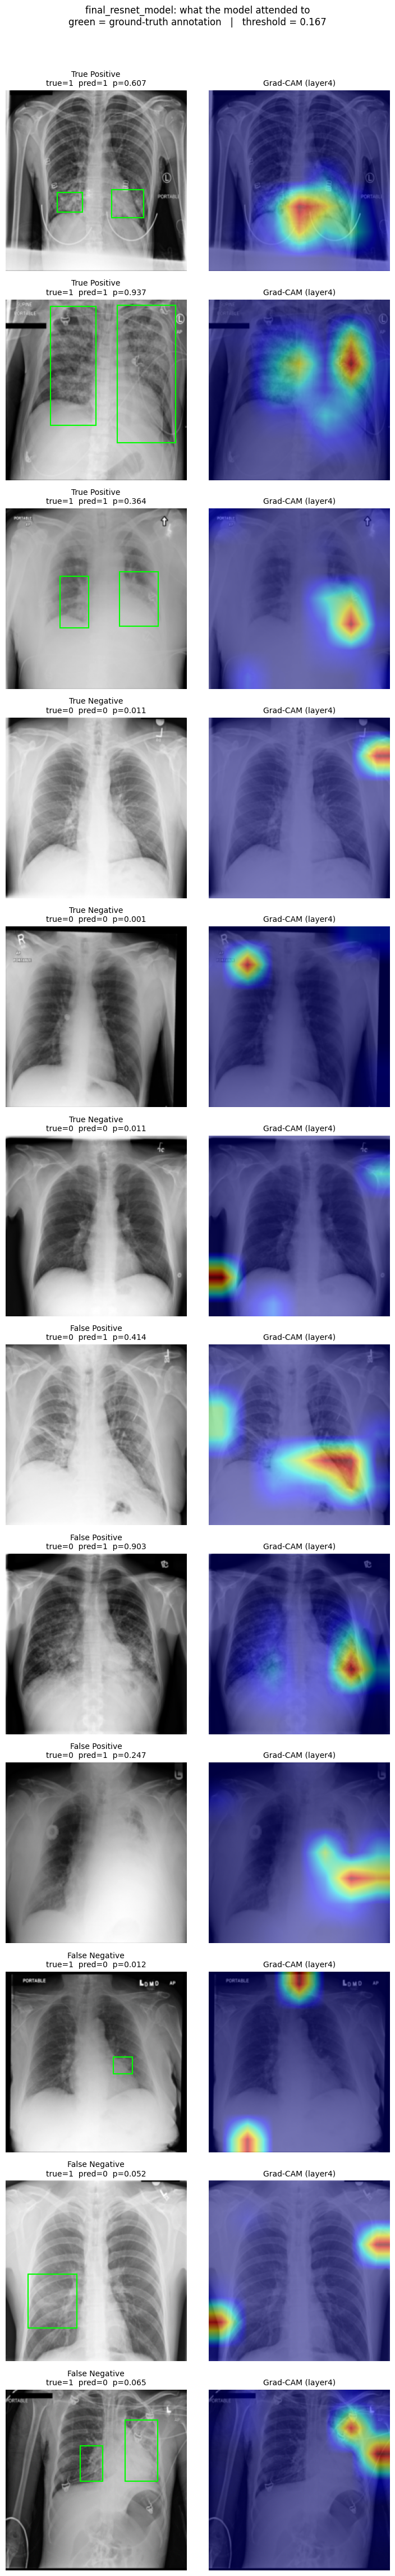


Pointing game on 200 positive images: 0.445 of peaks fall inside the annotation
Area-based chance level for these boxes: 0.111


In [188]:
import torch.nn.functional as F

# layer4 is the target of Grad-CAM, and the forward hook is registered on it.
final_resnet_model = make_resnet50()
final_resnet_model.load_state_dict(
    torch.load(
        "model_weight/best_model_1.pth",
        map_location=DEVICE,
        weights_only=True,
    )
)
final_resnet_model.eval()  # required: no BN stat updates, no dropout

# requires_grad is asserted rather than assumed. Grad-CAM needs a gradient of
# the score with respect to the layer4 activations. That gradient exists only
# because layer4 and fc are the unfrozen stages, so a fully frozen backbone
# would silently produce a zero or undefined gradient here.
CAM_LAYER = final_resnet_model.layer4
assert any(p.requires_grad for p in CAM_LAYER.parameters()), \
    "layer4 is fully frozen, gradients would not flow"

# ---------------------------------------------------------------------------
# 2. Test-set predictions
# ---------------------------------------------------------------------------
# Same global screening threshold as the confusion matrices earlier in the
# notebook, so these examples are the ones that section already talks about.
THRESHOLD = resnet_threshold[0]["threshold"]

probabilities = np.asarray(screening_resnet_result["probabilities"])
labels = test_df["Target"].to_numpy()

assert len(probabilities) == len(test_df), "Prediction order does not match the test set"

predictions = (probabilities >= THRESHOLD).astype(int)

groups = {
    "True Positive":  (labels == 1) & (predictions == 1),
    "True Negative":  (labels == 0) & (predictions == 0),
    "False Positive": (labels == 0) & (predictions == 1),
    "False Negative": (labels == 1) & (predictions == 0),
}

# ---------------------------------------------------------------------------
# 3. Preprocessing, identical to DICOM_dataset + eval_transform
# ---------------------------------------------------------------------------
# Reimplemented here instead of going through the Dataset so the raw array is
# available for display. Any mismatch between this and the training pipeline
# would put the heatmap on the wrong pixels, so the steps are kept in the same
# order as the dataset.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
INPUT_SIZE = 224


def load_image(path):
    """Return (model_input, displayable_uint8_grayscale)."""
    dcm = pydicom.dcmread(path)

    image = dcm.pixel_array.astype(np.float32)

    slope = float(getattr(dcm, "RescaleSlope", 1.0))
    intercept = float(getattr(dcm, "RescaleIntercept", 0.0))
    image = image * slope + intercept

    image = (image - image.min()) / (image.max() - image.min())

    original_size = image.shape[0]

    tensor = torch.from_numpy(image).float()[None, None]  # [1, 1, H, W]
    tensor = F.interpolate(
        tensor,
        size=(INPUT_SIZE, INPUT_SIZE),
        mode="bilinear",
        align_corners=False,
        antialias=True,
    )
    tensor = tensor.repeat(1, 3, 1, 1)  # [1, 3, 224, 224], grayscale in RGB

    # Resize and normalisation only; no augmentation on this path.
    mean = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
    tensor = (tensor - mean) / std

    display_image = (
        tensor[0, 0].detach().numpy() * float(std[0, 0, 0, 0])
        + float(mean[0, 0, 0, 0])
    )
    display_image = np.clip(display_image * 255.0, 0, 255).astype(np.uint8)

    return tensor.to(DEVICE), display_image, original_size


# ---------------------------------------------------------------------------
# 4. Grad-CAM
# ---------------------------------------------------------------------------
def grad_cam(model, layer, input_tensor, target_index=0):
    """Classic Grad-CAM: spatially averaged gradients weight the feature map.

    Returns a (H, W) array normalised to [0, 1], at the layer's own resolution.
    """
    activations = {}

    def capture(module, inputs, output):
        activations["value"] = output

    hook = layer.register_forward_hook(capture)

    try:
        # Input gradient is not strictly required here, but requesting it makes
        # the backward pass well defined no matter how the model is frozen.
        input_tensor = input_tensor.clone().requires_grad_(True)

        logits = model(input_tensor).reshape(-1)
        score = logits[target_index]

        gradients = torch.autograd.grad(
            outputs=score,
            inputs=activations["value"],
            retain_graph=False,
        )[0]
    finally:
        hook.remove()

    # Global average pooling of the gradients gives one weight per channel.
    weights = gradients.mean(dim=(2, 3), keepdim=True)

    cam = (weights * activations["value"]).sum(dim=1)  # [B, h, w]
    cam = F.relu(cam)

    cam = cam[0].detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    return cam


JET = plt.get_cmap("jet")


def overlay_cam(gray_uint8, cam, alpha=0.5):
    """Blend the CAM over the grayscale image, both at 224 x 224."""
    gray = gray_uint8.astype(np.float32) / 255.0
    heat = JET(cam)[..., :3]
    return np.clip((1 - alpha) * gray[..., None] + alpha * heat, 0, 1)


# ---------------------------------------------------------------------------
# 5. Choose the images
# ---------------------------------------------------------------------------
# One image from each of the four outcome groups, which guarantees at least one
# correct and one incorrect prediction as required. Raise IMAGES_PER_GROUP for
# a wider sample.
IMAGES_PER_GROUP = 1
HOW = "random"  # "most_confident", "borderline" or "random"


def select_examples(mask, probs, n=IMAGES_PER_GROUP, how=HOW, seed=SEED):
    candidates = np.flatnonzero(mask)

    if len(candidates) == 0:
        return candidates
    if len(candidates) <= n:
        return candidates

    by_confidence = candidates[np.argsort(probs[candidates])]

    if how == "most_confident":
        return by_confidence[-n:]
    if how == "borderline":
        return by_confidence[:n]

    return np.random.default_rng(seed).choice(candidates, size=n, replace=False)


selected = []

for name, mask in groups.items():
    for test_index in select_examples(mask, probabilities, 3):
        selected.append((name, int(test_index)))

has_correct = any(name in ("True Positive", "True Negative") for name, _ in selected)
has_incorrect = any(name in ("False Positive", "False Negative") for name, _ in selected)

assert has_correct and has_incorrect, \
    "Need at least one correct and one incorrect prediction"

n_correct = sum(1 for name, _ in selected if name in ("True Positive", "True Negative"))
n_incorrect = len(selected) - n_correct

print(f"Showing {len(selected)} images: {n_correct} correct, {n_incorrect} incorrect")

for name, test_index in selected:
    print(f"  {name:<15} test row {test_index:<6} "
          f"true={labels[test_index]} pred={predictions[test_index]} "
          f"p={probabilities[test_index]:.3f}")

# ---------------------------------------------------------------------------
# 6. Plot
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(
    len(selected), 2,
    figsize=(7.5, 3.9 * len(selected)),
    squeeze=False,
)

for row, (name, test_index) in enumerate(selected):
    record = test_df.iloc[test_index]

    input_tensor, display, original_size = load_image(record["File Path"])
    cam = grad_cam(final_resnet_model, CAM_LAYER, input_tensor)

    # Upsample the 7 x 7 map to image resolution. The result stays blocky by
    # construction; this is a localisation hint, not a segmentation mask.
    cam_up = F.interpolate(
        torch.from_numpy(cam)[None, None],
        size=(INPUT_SIZE, INPUT_SIZE),
        mode="bilinear",
        align_corners=False,
    )[0, 0].numpy()

    # Ground-truth annotation, rescaled from the 1024 x 1024 DICOM grid.
    scale = INPUT_SIZE / original_size

    for col, image in enumerate([display, overlay_cam(display, cam_up)]):
        ax = axes[row, col]
        ax.imshow(image, cmap="gray" if col == 0 else None)
        ax.axis("off")

        if col == 0:
            for box in record["Bounding Boxes"]:
                ax.add_patch(plt.Rectangle(
                    (box["x"] * scale, box["y"] * scale),
                    box["width"] * scale,
                    box["height"] * scale,
                    edgecolor="lime",
                    facecolor="none",
                    linewidth=1.5,
                ))

    axes[row, 0].set_title(
        f"{name}\ntrue={record['Target']}  pred={predictions[test_index]}  "
        f"p={probabilities[test_index]:.3f}",
        fontsize=10,
    )
    axes[row, 1].set_title("Grad-CAM (layer4)", fontsize=10)

plt.suptitle(
    "final_resnet_model: what the model attended to\n"
    f"green = ground-truth annotation   |   threshold = {THRESHOLD:.3f}",
    fontsize=12,
)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

# ---------------------------------------------------------------------------
# 7. Optional quantitative check: pointing game
# ---------------------------------------------------------------------------
# "Pointing game" accuracy asks whether the single most activated CAM cell falls
# inside a ground-truth box. It is a weak metric, but it is enough to show the
# map carries real localisation signal rather than being decorative. Computed on
# positive images only, since negatives have no box.
COMPUTE_POINTING_GAME = True
POINTING_GAME_N = 200

if COMPUTE_POINTING_GAME:
    positive_rows = np.flatnonzero(labels == 1)

    if len(positive_rows) > POINTING_GAME_N:
        positive_rows = np.random.default_rng(SEED).choice(
            positive_rows, size=POINTING_GAME_N, replace=False
        )

    hits = 0
    evaluated = 0
    box_areas = []

    for test_index in positive_rows:
        record = test_df.iloc[test_index]

        if not record["Bounding Boxes"]:
            continue

        input_tensor, _, original_size = load_image(record["File Path"])
        cam = grad_cam(final_resnet_model, CAM_LAYER, input_tensor)

        # Peak of the raw 7 x 7 map, mapped back into DICOM pixel coordinates.
        peak_row, peak_col = np.unravel_index(np.argmax(cam), cam.shape)
        peak_x = (peak_col + 0.5) * original_size / cam.shape[1]
        peak_y = (peak_row + 0.5) * original_size / cam.shape[0]

        inside = any(
            box["x"] <= peak_x <= box["x"] + box["width"]
            and box["y"] <= peak_y <= box["y"] + box["height"]
            for box in record["Bounding Boxes"]
        )

        hits += int(inside)
        evaluated += 1
        box_areas.append(min(
            sum(box["width"] * box["height"] for box in record["Bounding Boxes"]),
            original_size ** 2,
        ) / original_size ** 2)

    chance = float(np.mean(box_areas))

    print(f"\nPointing game on {evaluated} positive images: "
          f"{hits / evaluated:.3f} of peaks fall inside the annotation")
    print(f"Area-based chance level for these boxes: {chance:.3f}")

# Bonus

### Prevalence shift and threshold transfer

Frozen validation threshold: 0.1675


,test set,n,positives,negatives,requested prevalence,prevalence,thinned class,sensitivity,sensitivity 95% CI,specificity,specificity 95% CI,precision (PPV),F1,ROC-AUC
0,original test,2546,537,2009,—,0.211,none,0.881,"(np.float64(0.8506741778755509), np.float64(0.9055546329259851))",0.676,"(np.float64(0.65567843027893), np.float64(0.696559917736135))",0.421,0.570,0.870
1,10% target prevalence,2232,223,2009,0.100,0.100,positives,0.892,"(np.float64(0.8448585239177689), np.float64(0.9266049113604163))",0.676,"(np.float64(0.65567843027893), np.float64(0.696559917736135))",0.234,0.371,0.875
2,40% target prevalence,1342,537,805,0.400,0.400,negatives,0.881,"(np.float64(0.8506741778755509), np.float64(0.9055546329259851))",0.688,"(np.float64(0.6553681824790789), np.float64(0.7192416298747863))",0.653,0.750,0.876


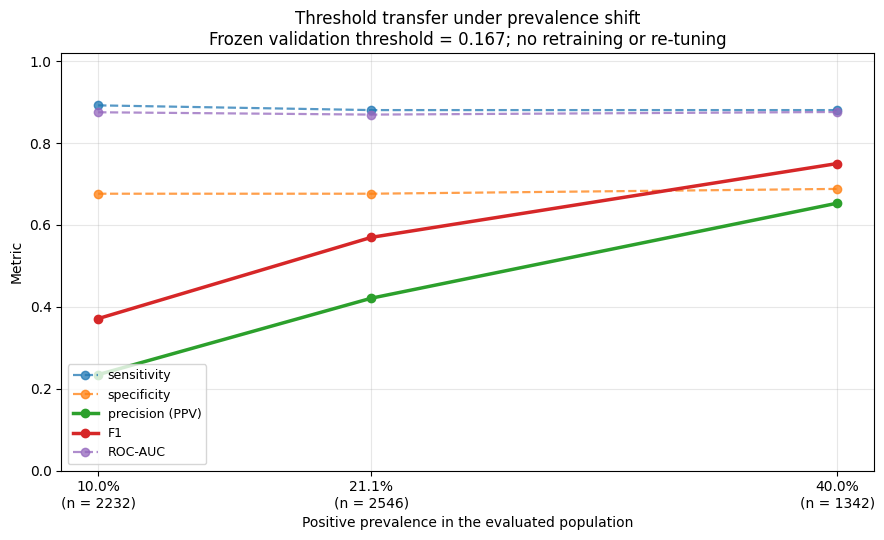

In [190]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
THRESHOLD = float(resnet_threshold[0]["threshold"])
TARGET_PREVALENCES = (0.10, 0.40)
SEED = 67

probabilities = np.asarray(
    screening_resnet_result["probabilities"],
    dtype=float,
).reshape(-1)

labels = test_df["Target"].to_numpy(dtype=int)

if len(probabilities) != len(labels):
    raise ValueError(
        f"Length mismatch: {len(probabilities)} probabilities but "
        f"{len(labels)} labels."
    )

if not np.isin(labels, [0, 1]).all():
    raise ValueError("Target must contain only binary labels 0 and 1.")

if not np.isfinite(probabilities).all():
    raise ValueError("Probabilities contain NaN or infinite values.")

if not 0 <= THRESHOLD <= 1:
    raise ValueError(f"Threshold must be in [0, 1], got {THRESHOLD}.")


# ---------------------------------------------------------------------------
# Prevalence-shifted subsets
# ---------------------------------------------------------------------------
def make_shifted_test_set(labels, target_prevalence, seed):
    """Randomly thin one class to approximate a requested prevalence.

    Sampling depends only on the true class label, never on model predictions
    or probabilities.
    """
    labels = np.asarray(labels)

    if not 0 < target_prevalence < 1:
        raise ValueError("target_prevalence must be strictly between 0 and 1.")

    positive_rows = np.flatnonzero(labels == 1)
    negative_rows = np.flatnonzero(labels == 0)

    n_positive_available = len(positive_rows)
    n_negative_available = len(negative_rows)

    if n_positive_available == 0 or n_negative_available == 0:
        raise ValueError("Both classes must be present in the original test set.")

    current_prevalence = (
        n_positive_available
        / (n_positive_available + n_negative_available)
    )

    # Avoid unnecessary resampling when the requested prevalence is already met.
    if np.isclose(target_prevalence, current_prevalence):
        rows = np.arange(len(labels))
        return rows, "none"

    rng = np.random.default_rng(seed)

    if target_prevalence < current_prevalence:
        # Keep all negatives and determine how many positives are required:
        # target = P / (P + N)
        n_positive_needed = round(
            target_prevalence
            * n_negative_available
            / (1 - target_prevalence)
        )

        if not 1 <= n_positive_needed <= n_positive_available:
            raise ValueError(
                f"Cannot obtain approximately {target_prevalence:.1%} prevalence: "
                f"need {n_positive_needed} positives, but "
                f"{n_positive_available} are available."
            )

        selected_positive_rows = rng.choice(
            positive_rows,
            size=n_positive_needed,
            replace=False,
        )
        selected_negative_rows = negative_rows
        thinned_class = "positives"

    else:
        # Keep all positives and determine how many negatives are required:
        # target = P / (P + N)
        n_negative_needed = round(
            (1 - target_prevalence)
            * n_positive_available
            / target_prevalence
        )

        if not 1 <= n_negative_needed <= n_negative_available:
            raise ValueError(
                f"Cannot obtain approximately {target_prevalence:.1%} prevalence: "
                f"need {n_negative_needed} negatives, but "
                f"{n_negative_available} are available."
            )

        selected_positive_rows = positive_rows
        selected_negative_rows = rng.choice(
            negative_rows,
            size=n_negative_needed,
            replace=False,
        )
        thinned_class = "negatives"

    rows = np.sort(
        np.concatenate([selected_positive_rows, selected_negative_rows])
    )

    return rows, thinned_class


# ---------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def wilson_interval(successes, total, z=1.96):
    """Two-sided Wilson score interval using the supplied normal critical value."""
    if total == 0:
        return (np.nan, np.nan)

    proportion = successes / total
    denominator = 1 + z**2 / total

    centre = (
        proportion + z**2 / (2 * total)
    ) / denominator

    margin = (
        z
        * np.sqrt(
            proportion * (1 - proportion) / total
            + z**2 / (4 * total**2)
        )
        / denominator
    )

    return (
        max(0.0, centre - margin),
        min(1.0, centre + margin),
    )


def evaluate_at_threshold(y_true, y_probability, threshold):
    y_true = np.asarray(y_true, dtype=int)
    y_probability = np.asarray(y_probability, dtype=float)
    y_predicted = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_predicted,
        labels=[0, 1],
    ).ravel()

    n_positive = tp + fn
    n_negative = tn + fp

    return {
        "n": len(y_true),
        "positives": n_positive,
        "negatives": n_negative,
        "prevalence": safe_divide(n_positive, len(y_true)),
        "sensitivity": safe_divide(tp, n_positive),
        "sensitivity 95% CI": wilson_interval(tp, n_positive),
        "specificity": safe_divide(tn, n_negative),
        "specificity 95% CI": wilson_interval(tn, n_negative),
        "precision (PPV)": precision_score(
            y_true,
            y_predicted,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_predicted,
            zero_division=0,
        ),
        "ROC-AUC": (
            roc_auc_score(y_true, y_probability)
            if np.unique(y_true).size == 2
            else np.nan
        ),
    }


# ---------------------------------------------------------------------------
# Construct and evaluate datasets
# ---------------------------------------------------------------------------
datasets = {
    "original test": {
        "rows": np.arange(len(labels)),
        "requested prevalence": np.nan,
        "thinned class": "none",
    }
}

# Give each target a reproducible but separate random-number stream.
child_seeds = np.random.SeedSequence(SEED).spawn(len(TARGET_PREVALENCES))

for target, child_seed in zip(TARGET_PREVALENCES, child_seeds):
    rows, thinned_class = make_shifted_test_set(
        labels,
        target_prevalence=target,
        seed=child_seed,
    )

    datasets[f"{target:.0%} target prevalence"] = {
        "rows": rows,
        "requested prevalence": target,
        "thinned class": thinned_class,
    }

results = {}

for name, dataset in datasets.items():
    rows = dataset["rows"]

    metrics = evaluate_at_threshold(
        labels[rows],
        probabilities[rows],
        THRESHOLD,
    )

    results[name] = {
        **dataset,
        **metrics,
    }


# ---------------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------------
report_columns = [
    "test set",
    "n",
    "positives",
    "negatives",
    "requested prevalence",
    "prevalence",
    "thinned class",
    "sensitivity",
    "sensitivity 95% CI",
    "specificity",
    "specificity 95% CI",
    "precision (PPV)",
    "F1",
    "ROC-AUC",
]

report = pd.DataFrame(
    [
        {
            "test set": name,
            **{
                column: result.get(column)
                for column in report_columns
                if column != "test set"
            },
        }
        for name, result in results.items()
    ]
)

numeric_columns = [
    "requested prevalence",
    "prevalence",
    "sensitivity",
    "specificity",
    "precision (PPV)",
    "F1",
    "ROC-AUC",
]

print(f"Frozen validation threshold: {THRESHOLD:.4f}")
display(
    report.style.format(
        {column: "{:.3f}" for column in numeric_columns},
        na_rep="—",
    )
)


# ---------------------------------------------------------------------------
# Plot in increasing prevalence order
# ---------------------------------------------------------------------------
metric_keys = [
    "sensitivity",
    "specificity",
    "precision (PPV)",
    "F1",
    "ROC-AUC",
]

ordered_results = sorted(
    results.items(),
    key=lambda item: item[1]["prevalence"],
)

fig, ax = plt.subplots(figsize=(9, 5.5))

for metric in metric_keys:
    prevalence_values = [
        result["prevalence"]
        for _, result in ordered_results
    ]
    metric_values = [
        result[metric]
        for _, result in ordered_results
    ]

    prevalence_sensitive = metric in {"precision (PPV)", "F1"}

    ax.plot(
        prevalence_values,
        metric_values,
        marker="o",
        linewidth=2.5 if prevalence_sensitive else 1.6,
        linestyle="-" if prevalence_sensitive else "--",
        alpha=1.0 if prevalence_sensitive else 0.75,
        label=metric,
    )

tick_positions = [
    result["prevalence"]
    for _, result in ordered_results
]

tick_labels = [
    f"{result['prevalence']:.1%}\n(n = {result['n']})"
    for _, result in ordered_results
]

ax.set(
    xlabel="Positive prevalence in the evaluated population",
    ylabel="Metric",
    title=(
        "Threshold transfer under prevalence shift\n"
        f"Frozen validation threshold = {THRESHOLD:.3f}; "
        "no retraining or re-tuning"
    ),
    ylim=(0, 1.02),
)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

### Border Problem

Running border-masked pass...
Running centre-control pass...


,condition,mean delta_p,median delta_p,sd delta_p,p5,p95,mean |delta_p|,p99 |delta_p|,max |delta_p|,flipped predictions,flip rate,0 -> 1,1 -> 0,AUC before,AUC after,Recall before,Recall after,Precision before,Precision after
0,border 8%,-0.081491,-0.02937,0.115003,-0.317653,0.015194,0.087473,0.443477,0.670346,307,0.120581,8,299,0.869794,0.866600,0.880819,0.787709,0.421193,0.508413
1,centre control,0.148378,0.19912,0.256914,-0.336363,0.502103,0.258949,0.610108,0.724434,1286,0.505106,1276,10,0.869794,0.745012,0.880819,0.988827,0.421193,0.222269


/tmp/slurm-faiz.ramadhan-209049/ipykernel_1423706/315247928.py:231: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


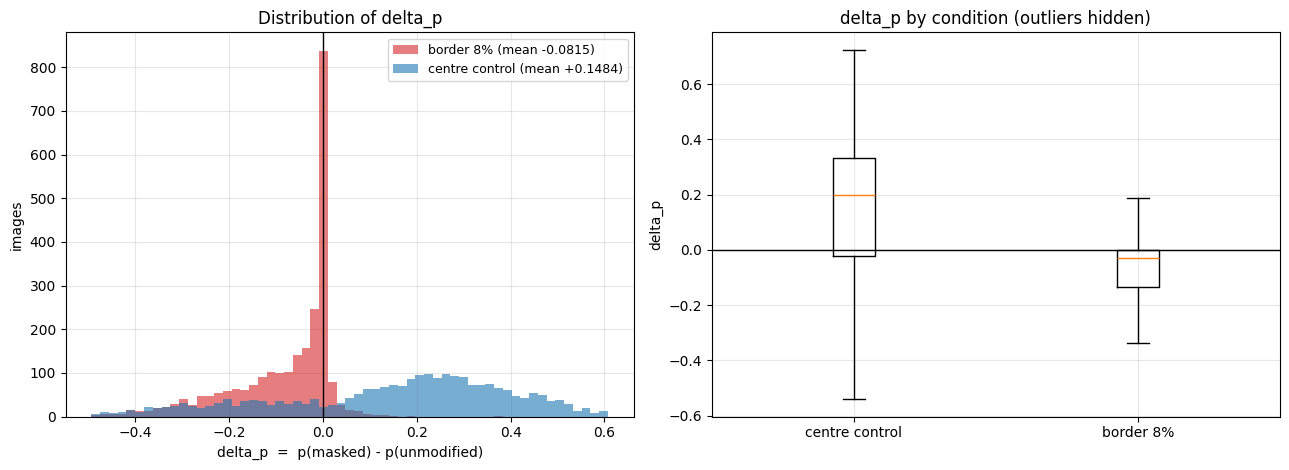

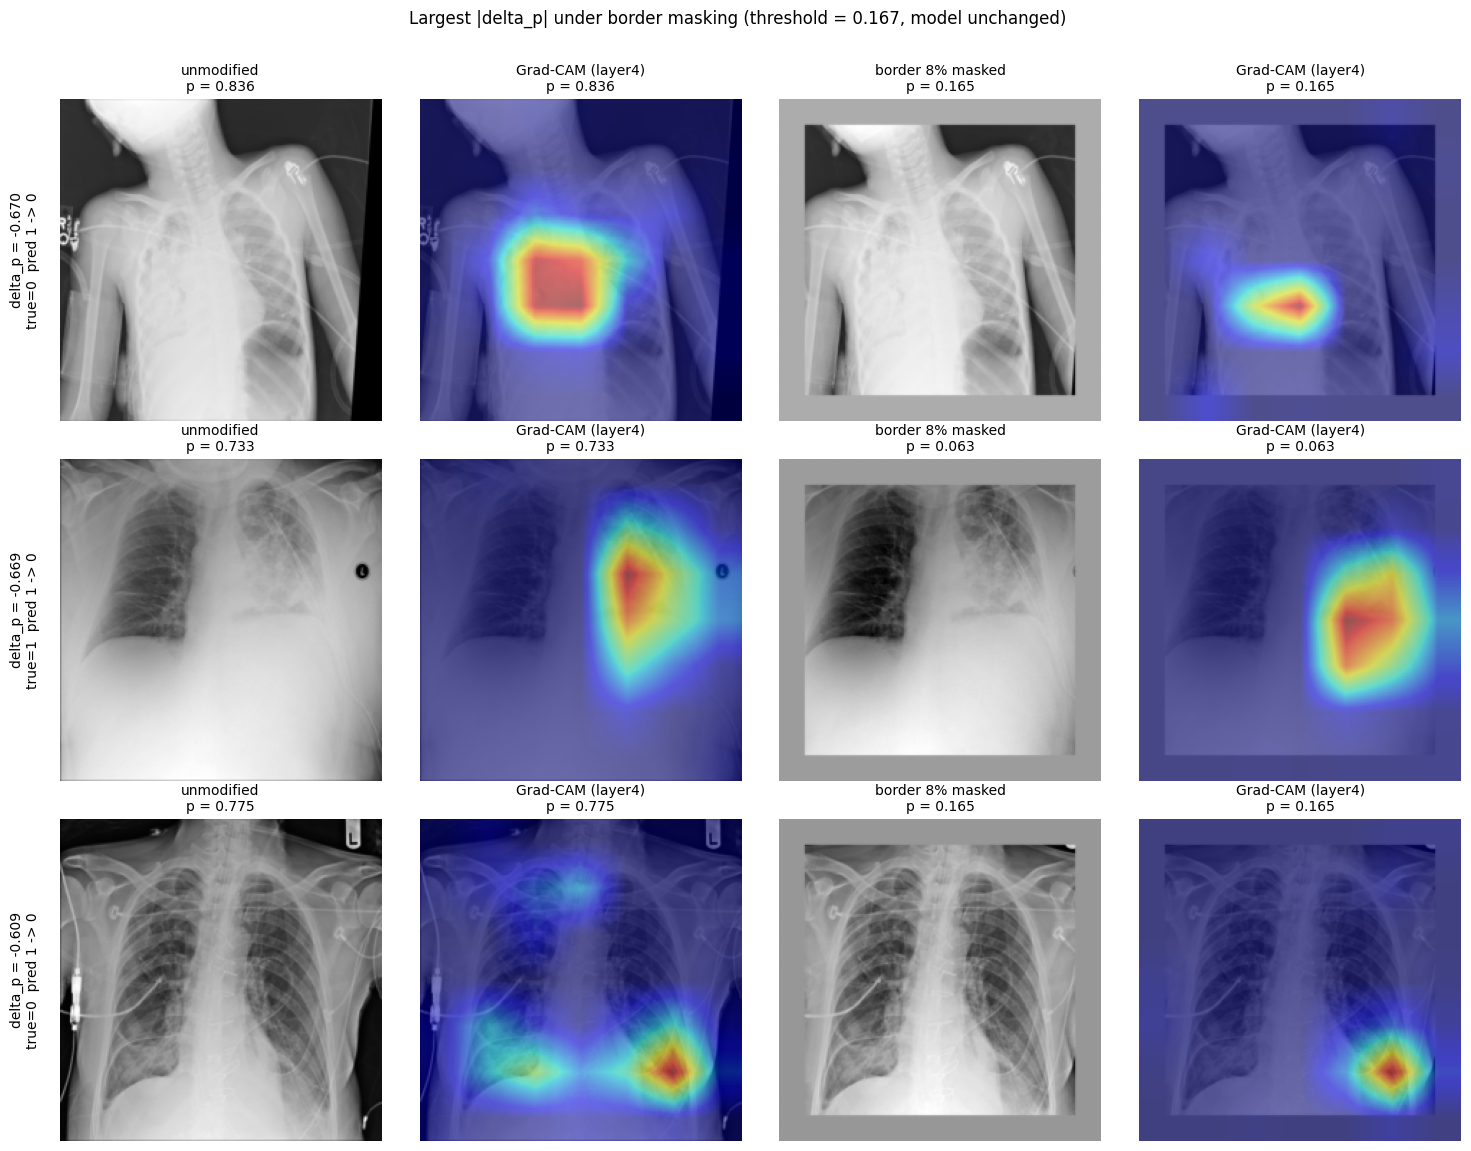

Saved 3 masked examples to masked_examples/
Border vs centre control
----------------------------------------------------------------------
mean delta_p      border -0.0815   control +0.1484
mean |delta_p|    border 0.0875   control 0.2589
max |delta_p|     border 0.6703   control 0.7244
flip rate         border 0.1206   control 0.5051
AUC               border 0.8698 -> 0.8666   control 0.8698 -> 0.7450

Ratio of mean |delta_p|, border over control: 0.34x


In [193]:
# ---------------------------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------------------------
BORDER_FRACTION = 0.08   # outer 8% of width and height on every side
FILL = "mean"            # "mean" or "zero"; see the note on normalisation below
BATCH_SIZE = 64
NUM_WORKERS = 4
THRESHOLD = resnet_threshold[0]["threshold"]
TOP_K = 3
SAVE_EXAMPLE_IMAGES = True

final_resnet_model = make_resnet50()
final_resnet_model.load_state_dict(
    torch.load("model_weight/best_model_1.pth", map_location=DEVICE, weights_only=True)
)
final_resnet_model.eval()

CAM_LAYER = final_resnet_model.layer4

# Unmodified test-set probabilities are already cached from the threshold
# section, so the baseline costs nothing and guarantees an exact comparison.
prob_baseline = np.asarray(screening_resnet_result["probabilities"])
labels = test_df["Target"].to_numpy()
assert len(prob_baseline) == len(test_df) == len(labels)

# ---------------------------------------------------------------------------
# 2. The deterministic transforms
# ---------------------------------------------------------------------------
# Both masks are pure functions of the image shape. No randomness, so the same
# pixel is masked on every run and the comparison is exactly reproducible.

def border_keep_mask(shape, fraction=BORDER_FRACTION):
    """False on the outer `fraction` of each side, True on the interior."""
    height, width = shape
    band_h = int(round(height * fraction))
    band_w = int(round(width * fraction))

    keep = np.zeros(shape, dtype=bool)
    keep[band_h:height - band_h, band_w:width - band_w] = True
    return keep


def center_box_keep_mask(shape, area_pixels):
    """Centred interior rectangle covering approximately `area_pixels` pixels.

    The side length is derived from the area so the control deletes the same
    number of pixels as the border mask. Centred placement guarantees the
    region sits inside the lung field and cannot overlap the border.
    """
    height, width = shape
    scale = np.sqrt(area_pixels / (height * width))
    box_h = int(round(height * scale))
    box_w = int(round(width * scale))

    top = (height - box_h) // 2
    left = (width - box_w) // 2

    keep = np.ones(shape, dtype=bool)
    keep[top:top + box_h, left:left + box_w] = False
    return keep


# ---------------------------------------------------------------------------
# 3. Dataset that mirrors DICOM_dataset + eval_transform
# ---------------------------------------------------------------------------
class MaskedDICOM_dataset(Dataset):
    """Identical to DICOM_dataset, with an optional deterministic transform.

    Two deliberate choices:

    * The mask is applied AFTER min-max normalisation. Applying it before would
      change the image's own min and max, shifting every pixel's intensity, and
      delta_p would then measure a global brightness change rather than the loss
      of peripheral information. Normalisation is therefore byte-identical to
      the baseline run and the only difference between the two is the masked
      pixels.
    * The fill is the image's own mean (after normalisation). A hard black frame
      is itself an out-of-distribution cue that the model could react to
      instead of reacting to missing information.
    """

    def __init__(self, df, image_col, label_col, transform=None, mask_builder=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform
        self.mask_builder = mask_builder

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        dcm = pydicom.dcmread(self.df.loc[index, self.image_col])
        image = dcm.pixel_array.astype(np.float32)

        slope = float(getattr(dcm, "RescaleSlope", 1.0))
        intercept = float(getattr(dcm, "RescaleIntercept", 0.0))
        image = image * slope + intercept

        image = (image - image.min()) / (image.max() - image.min())

        if self.mask_builder is not None:
            keep = self.mask_builder(image.shape)
            image = image.copy()
            image[~keep] = image[keep].mean() if FILL == "mean" else 0.0

        tensor = torch.from_numpy(image).float().unsqueeze(0)
        tensor = tensor.repeat(3, 1, 1)

        if self.transform is not None:
            tensor = self.transform(tensor)

        label = torch.tensor(self.df.loc[index, self.label_col], dtype=torch.float32)
        return tensor, label


def make_loader(mask_builder=None):
    dataset = MaskedDICOM_dataset(
        test_df, "File Path", "Target",
        transform=eval_transform,
        mask_builder=mask_builder,
    )
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,          # required: keeps alignment with test_df
        num_workers=NUM_WORKERS,
    )


@torch.inference_mode()
def predict(model, loader):
    model.eval()
    chunks = []
    for x, _ in loader:
        logits = model(x.to(DEVICE, non_blocking=True)).reshape(-1)
        chunks.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(chunks)


def border_mask_builder(image_shape):
    return border_keep_mask(image_shape)


# The control needs the border mask's pixel count for the *same* image, so the
# area is read off the shape rather than precomputed as a global constant.
def control_mask_builder_factory():
    def builder(image_shape):
        area = int((~border_keep_mask(image_shape, BORDER_FRACTION)).sum())
        return center_box_keep_mask(image_shape, area)
    return builder


# ---------------------------------------------------------------------------
# 4. Run both conditions
# ---------------------------------------------------------------------------
print("Running border-masked pass...")
prob_border = predict(final_resnet_model, make_loader(border_mask_builder))

print("Running centre-control pass...")
prob_control = predict(final_resnet_model, make_loader(control_mask_builder_factory()))

pred_baseline = (prob_baseline >= THRESHOLD).astype(int)
pred_border = (prob_border >= THRESHOLD).astype(int)
pred_control = (prob_control >= THRESHOLD).astype(int)

conditions = {
    "border 8%": prob_border,
    "centre control": prob_control,
}

# ---------------------------------------------------------------------------
# 5. Distribution of delta_p
# ---------------------------------------------------------------------------
rows = []

for name, prob in conditions.items():
    delta = prob - prob_baseline
    pred = pred_border if name.startswith("border") else pred_control
    flipped = pred != pred_baseline

    rows.append({
        "condition": name,
        "mean delta_p": delta.mean(),
        "median delta_p": np.median(delta),
        "sd delta_p": delta.std(ddof=1),
        "p5": np.percentile(delta, 5),
        "p95": np.percentile(delta, 95),
        "mean |delta_p|": np.abs(delta).mean(),
        "p99 |delta_p|": np.percentile(np.abs(delta), 99),
        "max |delta_p|": np.abs(delta).max(),
        "flipped predictions": int(flipped.sum()),
        "flip rate": flipped.mean(),
        "0 -> 1": int(((pred_baseline == 0) & (pred == 1)).sum()),
        "1 -> 0": int(((pred_baseline == 1) & (pred == 0)).sum()),
        "AUC before": roc_auc_score(labels, prob_baseline),
        "AUC after": roc_auc_score(labels, prob),
        "Recall before": recall_score(labels, pred_baseline),
        "Recall after": recall_score(labels, pred),
        "Precision before": precision_score(labels, pred_baseline),
        "Precision after": precision_score(labels, pred),
    })

summary = pd.DataFrame(rows)
display(summary)

# ---------------------------------------------------------------------------
# 6. Distribution figure
# ---------------------------------------------------------------------------
delta_border = prob_border - prob_baseline
delta_control = prob_control - prob_baseline

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Shared bin edges so the two histograms are directly comparable.
all_delta = np.concatenate([delta_border, delta_control])
edges = np.linspace(
    np.percentile(all_delta, 0.5),
    np.percentile(all_delta, 99.5),
    60,
)

axes[0].hist(delta_border, bins=edges, alpha=0.6, label=f"border 8% (mean {delta_border.mean():+.4f})", color="tab:red")
axes[0].hist(delta_control, bins=edges, alpha=0.6, label=f"centre control (mean {delta_control.mean():+.4f})", color="tab:blue")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlabel("delta_p  =  p(masked) - p(unmodified)")
axes[0].set_ylabel("images")
axes[0].set_title("Distribution of delta_p")
axes[0].legend(fontsize=9)

axes[1].boxplot(
    [delta_control, delta_border],
    labels=["centre control", "border 8%"],
    showfliers=False,
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("delta_p")
axes[1].set_title("delta_p by condition (outliers hidden)")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 7. Grad-CAM before and after, for the largest |delta_p|
# ---------------------------------------------------------------------------
# layer4 is frozen-backbone-unfriendly in one respect: only layer4 and fc are
# unfrozen, so any other layer's activations sit outside the autograd graph and
# autograd.grad would refuse them. Re-enabling grad on the single captured
# tensor is enough and costs no extra backward.
def grad_cam(model, layer, input_tensor):
    activations = {}

    def capture(module, inputs, output):
        if not output.requires_grad:
            output.requires_grad_(True)
        activations["value"] = output

    hook = layer.register_forward_hook(capture)
    try:
        logits = model(input_tensor.clone().requires_grad_(True)).reshape(-1)
        gradients = torch.autograd.grad(logits[0], activations["value"])[0]
    finally:
        hook.remove()

    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * activations["value"]).sum(dim=1))[0].detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)


JET = plt.get_cmap("jet")
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def tensor_to_gray(tensor):
    """Undo eval_transform's normalisation so the picture can be displayed."""
    image = tensor[0, 0].detach().cpu() * IMAGENET_STD[0, 0, 0, 0] + IMAGENET_MEAN[0, 0, 0, 0]
    return np.clip(image.numpy() * 255.0, 0, 255).astype(np.uint8)


def overlay(gray_uint8, cam, alpha=0.5):
    gray = gray_uint8.astype(np.float32) / 255.0
    return np.clip((1 - alpha) * gray[..., None] + alpha * JET(cam)[..., :3], 0, 1)


def masked_input_for(record, builder):
    """Single-image path through the same transform, for Grad-CAM."""
    dcm = pydicom.dcmread(record["File Path"])
    image = dcm.pixel_array.astype(np.float32)
    image = image * float(getattr(dcm, "RescaleSlope", 1.0)) + float(getattr(dcm, "RescaleIntercept", 0.0))
    image = (image - image.min()) / (image.max() - image.min())

    if builder is not None:
        keep = builder(image.shape)
        image = image.copy()
        image[~keep] = image[keep].mean() if FILL == "mean" else 0.0

    tensor = torch.from_numpy(image).float()[None, None].repeat(1, 3, 1, 1)
    return eval_transform(tensor).to(DEVICE)


# Largest absolute change, whichever direction it went.
top_rows = np.argsort(-np.abs(delta_border))[:TOP_K]

fig, axes = plt.subplots(len(top_rows), 4, figsize=(15, 3.9 * len(top_rows)), squeeze=False)

for row, test_index in enumerate(top_rows):
    record = test_df.iloc[test_index]

    panels = [
        ("unmodified", masked_input_for(record, None), prob_baseline[test_index]),
        ("border 8% masked", masked_input_for(record, border_mask_builder), prob_border[test_index]),
    ]

    for col, (label, tensor, probability) in enumerate(panels):
        gray = tensor_to_gray(tensor)
        cam = grad_cam(final_resnet_model, CAM_LAYER, tensor)
        cam = F.interpolate(
            torch.from_numpy(cam)[None, None],
            size=gray.shape, mode="bilinear", align_corners=False,
        )[0, 0].numpy()

        axes[row, col * 2].imshow(gray, cmap="gray")
        axes[row, col * 2].set_title(f"{label}\np = {probability:.3f}", fontsize=10)
        axes[row, col * 2].axis("off")

        axes[row, col * 2 + 1].imshow(overlay(gray, cam))
        axes[row, col * 2 + 1].set_title(f"Grad-CAM (layer4)\np = {probability:.3f}", fontsize=10)
        axes[row, col * 2 + 1].axis("off")

    for col in range(4):
        axes[row, col].set_ylabel("")

    axes[row, 0].text(
        -0.06, 0.5,
        f"delta_p = {delta_border[test_index]:+.3f}\n"
        f"true={record['Target']}  pred {pred_baseline[test_index]} -> {pred_border[test_index]}",
        transform=axes[row, 0].transAxes,
        rotation=90, va="center", ha="right", fontsize=10,
    )

plt.suptitle(
    f"Largest |delta_p| under border masking "
    f"(threshold = {THRESHOLD:.3f}, model unchanged)",
    fontsize=12,
)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

if SAVE_EXAMPLE_IMAGES:
    import os
    os.makedirs("masked_examples", exist_ok=True)
    for test_index in top_rows:
        gray = tensor_to_gray(masked_input_for(test_df.iloc[test_index], border_mask_builder))
        plt.imsave(
            f"masked_examples/border_{test_df.iloc[test_index]['SOPInstanceUID'][-12:]}.png",
            gray, cmap="gray",
        )
    print(f"Saved {len(top_rows)} masked examples to masked_examples/")

# ---------------------------------------------------------------------------
# 8. Interpretation
# ---------------------------------------------------------------------------
border_row = summary.iloc[0]
control_row = summary.iloc[1]

print("Border vs centre control")
print("-" * 70)
print(f"mean delta_p      border {border_row['mean delta_p']:+.4f}   "
      f"control {control_row['mean delta_p']:+.4f}")
print(f"mean |delta_p|    border {border_row['mean |delta_p|']:.4f}   "
      f"control {control_row['mean |delta_p|']:.4f}")
print(f"max |delta_p|     border {border_row['max |delta_p|']:.4f}   "
      f"control {control_row['max |delta_p|']:.4f}")
print(f"flip rate         border {border_row['flip rate']:.4f}   "
      f"control {control_row['flip rate']:.4f}")
print(f"AUC               border {border_row['AUC before']:.4f} -> {border_row['AUC after']:.4f}   "
      f"control {control_row['AUC before']:.4f} -> {control_row['AUC after']:.4f}")
print(
    f"\nRatio of mean |delta_p|, border over control: "
    f"{border_row['mean |delta_p|'] / max(control_row['mean |delta_p|'], 1e-12):.2f}x"
)
